# 🤖 NewsBot Intelligence System
## ITAI 2373 - Mid-Term Project

**Project Type:** Individual Project — Viktoriya Kurmisheva

**Peer Reviewer / Tester:** Abraham Barreto  

**Informal Review Team:** Team Testers

**Date:** June 24, 2026

**GitHub Repository:** https://github.com/viksus164/ITAI2373-NewsBot-Midterm

---

## 🎯 Project Overview

Welcome to your NewsBot Intelligence System! This notebook will guide you through building a comprehensive NLP system that:

- 📰 **Processes** news articles with advanced text cleaning
- 🏷️ **Classifies** articles into categories (Politics, Sports, Technology, Business, Entertainment, Health)
- 🔍 **Extracts** named entities (people, organizations, locations, dates, money)
- 😊 **Analyzes** sentiment and emotional tone
- 📊 **Generates** insights for business intelligence

### 📚 Module Integration Checklist
- [ ] **Module 1:** NLP applications and real-world context
- [ ] **Module 2:** Text preprocessing pipeline
- [ ] **Module 3:** TF-IDF feature extraction
- [ ] **Module 4:** POS tagging analysis
- [ ] **Module 5:** Syntax parsing and semantic analysis
- [ ] **Module 6:** Sentiment and emotion analysis
- [ ] **Module 7:** Text classification system
- [ ] **Module 8:** Named Entity Recognition

---


## 📦 Setup and Installation

Let's start by installing and importing all the libraries we'll need for our NewsBot system.

In [2]:
# Install required packages (run this cell first!)
!pip install spacy scikit-learn nltk pandas matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')

print("✅ All packages installed successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


✅ All packages installed successfully!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


## Data Loading and Exploration

This section loads the BBC News Classification dataset, standardizes the required columns, and verifies the project dataset rules: at least 500 English articles, at least 4 labeled categories, substantial article text, no missing text/category values, and fewer than 2,000 records for Colab performance.

The exploration also checks class balance, source information, text length, missing values, and duplicate/quality issues before any modeling is done.


In [4]:
# Load the real BBC News Classification dataset instead of the small starter sample.
# Default method: upload the learn-ai-bbc.zip file you already downloaded.
# Optional method: set USE_DOWNLOADED_ZIP to False to download from Kaggle using kaggle.json.

from pathlib import Path
import zipfile

# Keep this True if you want to upload the ZIP file manually in Colab.
USE_DOWNLOADED_ZIP = True

# Create a folder where the dataset files will be extracted.
DATA_FOLDER = Path("bbc_data")
DATA_FOLDER.mkdir(exist_ok=True)

if USE_DOWNLOADED_ZIP:
    from google.colab import files

    # Ask the user to upload the downloaded Kaggle ZIP file.
    print("Upload learn-ai-bbc.zip from your Downloads folder.")
    uploaded = files.upload()

    # Find the uploaded ZIP file.
    zip_name = next((name for name in uploaded if name.lower().endswith(".zip")), None)

    # Stop the notebook if no ZIP file was uploaded.
    if zip_name is None:
        raise ValueError("Please upload learn-ai-bbc.zip.")

    # Extract the uploaded ZIP file into the data folder.
    with zipfile.ZipFile(zip_name) as archive:
        archive.extractall(DATA_FOLDER)

else:
    # kaggle.json contains private credentials, so do not commit it to GitHub.
    from google.colab import files

    print("Upload kaggle.json from your Kaggle account.")
    uploaded = files.upload()

    # Make sure the Kaggle credentials file was uploaded.
    if "kaggle.json" not in uploaded:
        raise ValueError("Please upload kaggle.json.")

    # Set up Kaggle credentials inside Colab.
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # Download and unzip the BBC dataset from Kaggle.
    !kaggle competitions download -c learn-ai-bbc -p bbc_data
    !unzip -o bbc_data/learn-ai-bbc.zip -d bbc_data

# Read the extracted BBC training CSV file.
raw_df = pd.read_csv(DATA_FOLDER / "BBC News Train.csv")

# Rename the original Kaggle columns to simpler names used throughout the notebook.
df = raw_df.rename(
    columns={
        "ArticleId": "article_id",
        "Text": "content",
        "Category": "category"
    }
)[["article_id", "content", "category"]].copy()

# Clean text and category columns so there are no missing or messy values.
df["content"] = df["content"].fillna("").astype(str).str.strip()
df["category"] = df["category"].fillna("").astype(str).str.strip()

# The BBC dataset does not include titles, so create a short title from the article text.
df["title"] = (
    df["content"]
    .str.split(r"\s{2,}|\n", n=1)
    .str[0]
    .str.split()
    .str[:16]
    .str.join(" ")
    .str.title()
)

# Add source information for documentation.
df["source"] = "BBC News Classification (Kaggle)"

# The supplied BBC file does not include verified publication dates.
df["date"] = pd.NaT

# Keep only articles with substantial text and valid category labels.
df = df[
    (df["content"].str.len() >= 200) &
    (df["category"].str.len() > 0)
].copy()

# Check that the dataset meets the assignment requirements.
requirements = {
    "At least 500 articles": len(df) >= 500,
    "At least 4 categories": df["category"].nunique() >= 4,
    "At most 2,000 articles": len(df) <= 2000,
    "No missing text": df["content"].notna().all() and df["content"].str.len().gt(0).all(),
    "No missing category": df["category"].notna().all() and df["category"].str.len().gt(0).all(),
    "Substantial article text": df["content"].str.len().ge(200).all(),
}

# Display the requirement checklist.
display(pd.DataFrame({
    "Requirement": requirements.keys(),
    "Passed": requirements.values()
}))

# Stop the notebook if any requirement fails.
assert all(requirements.values()), "Dataset validation failed."

# Confirm successful loading and preview the dataset.
print(f"Loaded {len(df)} English BBC articles in {df['category'].nunique()} categories.")
display(df.head())

Upload learn-ai-bbc.zip from your Downloads folder.


Saving learn-ai-bbc.zip to learn-ai-bbc.zip


,Requirement,Passed
0,At least 500 articles,True
1,At least 4 categories,True
2,"At most 2,000 articles",True
3,No missing text,True
4,No missing category,True
5,Substantial article text,True


Loaded 1490 English BBC articles in 5 categories.


,article_id,content,category,title,source,date
0,1833,worldcom ex-boss launches defence lawyers defe...,business,Worldcom Ex-Boss Launches Defence Lawyers Defe...,BBC News Classification (Kaggle),NaT
1,154,german business confidence slides german busin...,business,German Business Confidence Slides German Busin...,BBC News Classification (Kaggle),NaT
2,1101,bbc poll indicates economic gloom citizens in ...,business,Bbc Poll Indicates Economic Gloom Citizens In ...,BBC News Classification (Kaggle),NaT
3,1976,lifestyle governs mobile choice faster bett...,tech,Lifestyle,BBC News Classification (Kaggle),NaT
4,917,enron bosses in $168m payout eighteen former e...,business,Enron Bosses In $168M Payout Eighteen Former E...,BBC News Classification (Kaggle),NaT


DATASET OVERVIEW
Total articles: 1490
Unique categories: 5
Categories: ['business', 'tech', 'politics', 'sport', 'entertainment']
Date range: Not available in the BBC Kaggle training file
Unique sources: 1

CATEGORY DISTRIBUTION
category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

DATA QUALITY CHECKS
Missing values by column:
article_id       0
title            0
content          0
category         0
source           0
date          1490
dtype: int64
Note: date is missing because the BBC Kaggle training file does not include verified publication dates; this is handled later through temporal-reference analysis.

Article length summary:
       content_char_length  content_word_count  title_word_count
count              1490.00             1490.00           1490.00
mean               2233.46              385.01             13.10
std                1205.15              210.90              5.17
min      

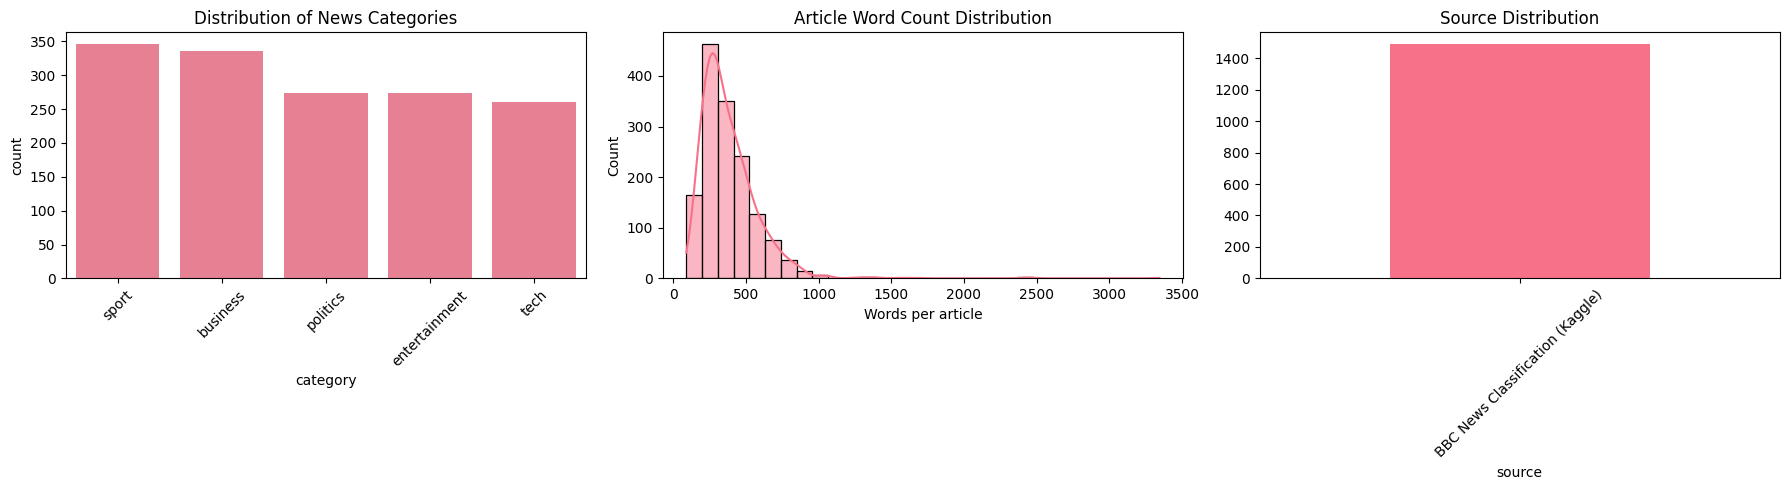

In [5]:
# Show the main dataset information so we can confirm the data loaded correctly.
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total articles: {len(df)}")
print(f"Unique categories: {df['category'].nunique()}")
print(f"Categories: {df['category'].unique().tolist()}")

# The BBC dataset does not include real publication dates, so most values are NaT.
if df['date'].notna().any():
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
else:
    print("Date range: Not available in the BBC Kaggle training file")

# Show how many sources are represented in the dataset.
print(f"Unique sources: {df['source'].nunique()}")

# Count how many articles belong to each news category.
print("\nCATEGORY DISTRIBUTION")
print("=" * 50)
category_counts = df['category'].value_counts()
print(category_counts)

# Check for missing values in the important dataset columns.
print("\nDATA QUALITY CHECKS")
print("=" * 50)
missing_summary = df[['article_id', 'title', 'content', 'category', 'source', 'date']].isna().sum()
print("Missing values by column:")
print(missing_summary)

# Explain why the date column is missing so it does not look like an error.
print("Note: date is missing because the BBC Kaggle training file does not include verified publication dates; this is handled later through temporal-reference analysis.")

# Create length-based columns for article quality and text-size analysis.
df['content_char_length'] = df['content'].astype(str).str.len()
df['content_word_count'] = df['content'].astype(str).str.split().str.len()
df['title_word_count'] = df['title'].astype(str).str.split().str.len()

# Summarize article and title lengths.
print("\nArticle length summary:")
print(df[['content_char_length', 'content_word_count', 'title_word_count']].describe().round(2))

# Count articles by source.
source_counts = df['source'].value_counts()
print("\nSource distribution:")
print(source_counts)

# Check for common data-quality problems.
duplicate_articles = df.duplicated(subset=['content']).sum()
short_articles = (df['content_word_count'] < 50).sum()
empty_titles = (df['title'].astype(str).str.strip() == '').sum()

# Put the quality checks into a small readable table.
quality_summary = pd.DataFrame({
    'Check': [
        'Duplicate article bodies',
        'Articles under 50 words',
        'Empty derived titles',
        'Missing category values',
        'Missing content values'
    ],
    'Count': [
        duplicate_articles,
        short_articles,
        empty_titles,
        df['category'].isna().sum(),
        df['content'].isna().sum()
    ]
})
print("\nQuality issue summary:")
print(quality_summary)

# Confirm that the dataset satisfies the assignment requirements.
requirement_check = pd.DataFrame({
    'Requirement': [
        'At least 500 articles',
        'At least 4 categories',
        'At most 2,000 articles',
        'No missing article text',
        'No missing category labels',
        'Substantial article text'
    ],
    'Passed': [
        len(df) >= 500,
        df['category'].nunique() >= 4,
        len(df) <= 2000,
        df['content'].notna().all(),
        df['category'].notna().all(),
        (df['content_word_count'] >= 50).all()
    ]
})
print("\nDataset requirement confirmation:")
print(requirement_check)

# Create three quick visualizations for category balance, article length, and source distribution.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart showing how many articles are in each category.
sns.countplot(data=df, x='category', order=category_counts.index, ax=axes[0])
axes[0].set_title('Distribution of News Categories')
axes[0].tick_params(axis='x', rotation=45)

# Histogram showing how long the articles are.
sns.histplot(df['content_word_count'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Article Word Count Distribution')
axes[1].set_xlabel('Words per article')

# Bar chart showing where the articles came from.
source_counts.plot(kind='bar', ax=axes[2])
axes[2].set_title('Source Distribution')
axes[2].tick_params(axis='x', rotation=45)

# Adjust spacing so the plots do not overlap.
plt.tight_layout()
plt.show()

## Text Preprocessing Pipeline

This section turns raw article text into model-ready text. The cleaning pipeline removes HTML, URLs, email addresses, punctuation/numbers, extra spaces, stop words, and applies lemmatization.

The output keeps both the original article text and processed text so later sections can compare human-readable examples with the cleaned features used by TF-IDF and machine-learning models.


In [6]:
# Initialize the lemmatizer, which reduces words to their base form.
# Example: "earnings" may become "earning".
lemmatizer = WordNetLemmatizer()

# Load the standard English stop words, such as "the", "is", "and", and "of".
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean raw article text for NLP processing.

    The function removes HTML tags, URLs, email addresses, digits,
    punctuation/special characters, and extra whitespace. It returns
    lowercase alphabetic text that is easier to tokenize and model.
    """
    # If the text is missing, return an empty string so later code does not crash.
    if pd.isna(text):
        return ""

    # Convert text to lowercase so words like "Apple" and "apple" are treated the same.
    text = str(text).lower()

    # Remove HTML tags, such as <p>, <br>, or <div>.
    text = re.sub(r'<[^>]+>', '', text)

    # Remove website links.
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses.
    text = re.sub(r'\S+@\S+', '', text)

    # Keep only letters and spaces.
    # This removes numbers, punctuation, hashtags, and special symbols.
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Replace multiple spaces with one space and remove spaces at the start/end.
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Run the full preprocessing pipeline on a text string.

    Steps:
    1. Clean the raw text.
    2. Tokenize into words.
    3. Optionally remove English stop words.
    4. Optionally lemmatize words.
    5. Remove very short tokens.

    Returns a single processed string suitable for TF-IDF modeling.
    """
    # First clean the raw text.
    text = clean_text(text)

    # If cleaning removed everything, return an empty string.
    if not text:
        return ""

    # Split the cleaned text into individual word tokens.
    tokens = word_tokenize(text)

    # Remove common words that usually do not add much meaning.
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # Reduce words to their base form.
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Remove very short tokens because they are usually not informative.
    tokens = [token for token in tokens if len(token) > 2]

    # Join the cleaned tokens back into one processed text string.
    return ' '.join(tokens)

# Test the preprocessing pipeline with a short sample sentence.
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews"

# Show the original text before cleaning.
print("Original text:")
print(sample_text)

# Show text after basic cleaning only.
print("\nCleaned text:")
print(clean_text(sample_text))

# Show text after the full preprocessing pipeline.
print("\nFully preprocessed text:")
print(preprocess_text(sample_text))

Original text:
Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews

Cleaned text:
apple inc announced record quarterly earnings today visit for more info technews

Fully preprocessed text:
apple inc announced record quarterly earnings today visit info technews


Preprocessing all articles...
Preprocessing complete!

BEFORE AND AFTER EXAMPLES

Example 1:
Original: Worldcom Ex-Boss Launches Defence Lawyers Defending Former Worldcom Chief Bernie Ebbers Against A Ba...
Processed: worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers battery fraud wo...

Example 2:
Original: German Business Confidence Slides German Business Confidence Fell In February Knocking Hopes Of A Sp...
Processed: german business confidence slide german business confidence fell february knocking hope speedy recov...

Example 3:
Original: Bbc Poll Indicates Economic Gloom Citizens In A Majority Of Nations Surveyed In A Bbc World bbc poll...
Processed: bbc poll indicates economic gloom citizen majority nation surveyed bbc world bbc poll indicates econ...

PREPROCESSING SUMMARY
                                Metric     Value
0        Average raw words per article    398.12
1  Average processed words per article    215.94
2           Average word r

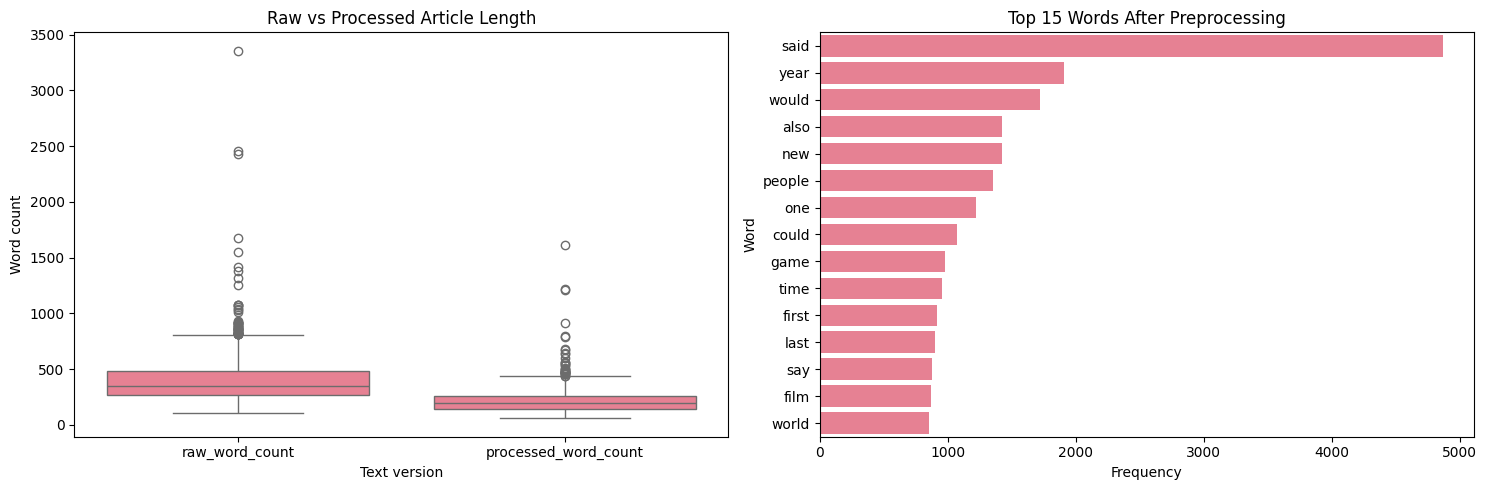

In [7]:
# Apply cleaning and preprocessing to title, content, and combined full text.
print("Preprocessing all articles...")

df['title_clean'] = df['title'].apply(clean_text)
df['content_clean'] = df['content'].apply(clean_text)
df['title_processed'] = df['title'].apply(preprocess_text)
df['content_processed'] = df['content'].apply(preprocess_text)

# Combine title and content so later analysis uses the full article context.
df['full_text'] = df['title'] + ' ' + df['content']
df['full_text_processed'] = df['full_text'].apply(preprocess_text)

print("Preprocessing complete!")

# Show a few examples to compare the original and processed versions.
print("\nBEFORE AND AFTER EXAMPLES")
print("=" * 60)
for i in range(min(3, len(df))):
    print(f"\nExample {i+1}:")
    print(f"Original: {df.iloc[i]['full_text'][:100]}...")
    print(f"Processed: {df.iloc[i]['full_text_processed'][:100]}...")

# Measure how preprocessing changed article length and vocabulary size.
df['raw_word_count'] = df['full_text'].astype(str).str.split().str.len()
df['processed_word_count'] = df['full_text_processed'].astype(str).str.split().str.len()
df['preprocessing_reduction_pct'] = (
    1 - (df['processed_word_count'] / df['raw_word_count'].replace(0, np.nan))
) * 100

raw_tokens = ' '.join(df['full_text'].apply(clean_text)).split()
processed_tokens = ' '.join(df['full_text_processed']).split()

preprocessing_summary = pd.DataFrame({
    'Metric': [
        'Average raw words per article',
        'Average processed words per article',
        'Average word reduction (%)',
        'Unique raw words',
        'Unique processed words'
    ],
    'Value': [
        df['raw_word_count'].mean(),
        df['processed_word_count'].mean(),
        df['preprocessing_reduction_pct'].mean(),
        len(set(raw_tokens)),
        len(set(processed_tokens))
    ]
})

print("\nPREPROCESSING SUMMARY")
print(preprocessing_summary.round(2))

# Identify the most frequent words remaining after preprocessing.
common_processed_words = pd.DataFrame(
    Counter(processed_tokens).most_common(20),
    columns=['word', 'count']
)

print("\nMost common processed words:")
print(common_processed_words)

# Visualize text reduction and common processed words.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

length_compare = df[['raw_word_count', 'processed_word_count']].melt(
    var_name='Text version',
    value_name='Word count'
)

sns.boxplot(data=length_compare, x='Text version', y='Word count', ax=axes[0])
axes[0].set_title('Raw vs Processed Article Length')

sns.barplot(data=common_processed_words.head(15), x='count', y='word', ax=axes[1])
axes[1].set_title('Top 15 Words After Preprocessing')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

# Prevent plot labels from overlapping.
plt.tight_layout()
plt.show()

## Feature Extraction and Statistical Analysis

This section converts articles into TF-IDF features. TF-IDF highlights words and phrases that are important within a category while reducing the weight of very common words.

The analysis identifies the most important terms for each news category and visualizes category-specific language patterns.


In [8]:
# Create TF-IDF vectorizer
# - max_features: limit vocabulary size
# - ngram_range: include phrases (1,1) for words, (1,2) for words+bigrams
# - min_df: ignore terms that appear in less than min_df documents
# - max_df: ignore terms that appear in more than max_df fraction of documents

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary for computational efficiency
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.8  # Ignore terms that appear in more than 80% of documents
)

# Fit and transform the processed text
print("🔢 Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['full_text_processed'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix created!")
print(f"📊 Shape: {tfidf_matrix.shape}")
print(f"📝 Vocabulary size: {len(feature_names)}")
print(f"🔢 Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Convert to DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['category'] = df['category'].values

print("\n🔍 Sample TF-IDF features:")
print(tfidf_df.iloc[:3, :10])  # Show first 3 rows and 10 features

🔢 Creating TF-IDF features...
✅ TF-IDF matrix created!
📊 Shape: (1490, 5000)
📝 Vocabulary size: 5000
🔢 Sparsity: 97.50%

🔍 Sample TF-IDF features:
   abbas  abc  ability  able  abroad  absence  absolute  absolutely  abuse  \
0    0.0  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0   
1    0.0  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0   
2    0.0  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0   

   abused  
0     0.0  
1     0.0  
2     0.0  


TOP TF-IDF TERMS BY CATEGORY

BUSINESS:
  firm: 0.0380
  company: 0.0340
  bank: 0.0336
  growth: 0.0324
  share: 0.0324
  market: 0.0317
  economy: 0.0316
  sale: 0.0308
  year: 0.0308
  profit: 0.0284

TECH:
  mobile: 0.0528
  phone: 0.0468
  people: 0.0447
  technology: 0.0396
  game: 0.0377
  user: 0.0366
  service: 0.0358
  software: 0.0354
  computer: 0.0329
  microsoft: 0.0326

POLITICS:
  labour: 0.0653
  election: 0.0595
  blair: 0.0595
  party: 0.0526
  tory: 0.0478
  government: 0.0439
  would: 0.0434
  minister: 0.0421
  brown: 0.0402
  tax: 0.0325

SPORT:
  game: 0.0400
  england: 0.0378
  win: 0.0314
  player: 0.0289
  champion: 0.0275
  cup: 0.0272
  match: 0.0272
  chelsea: 0.0255
  coach: 0.0242
  ireland: 0.0233

ENTERTAINMENT:
  film: 0.0987
  award: 0.0489
  best: 0.0423
  star: 0.0393
  show: 0.0364
  music: 0.0344
  actor: 0.0340
  band: 0.0336
  oscar: 0.0287
  singer: 0.0276


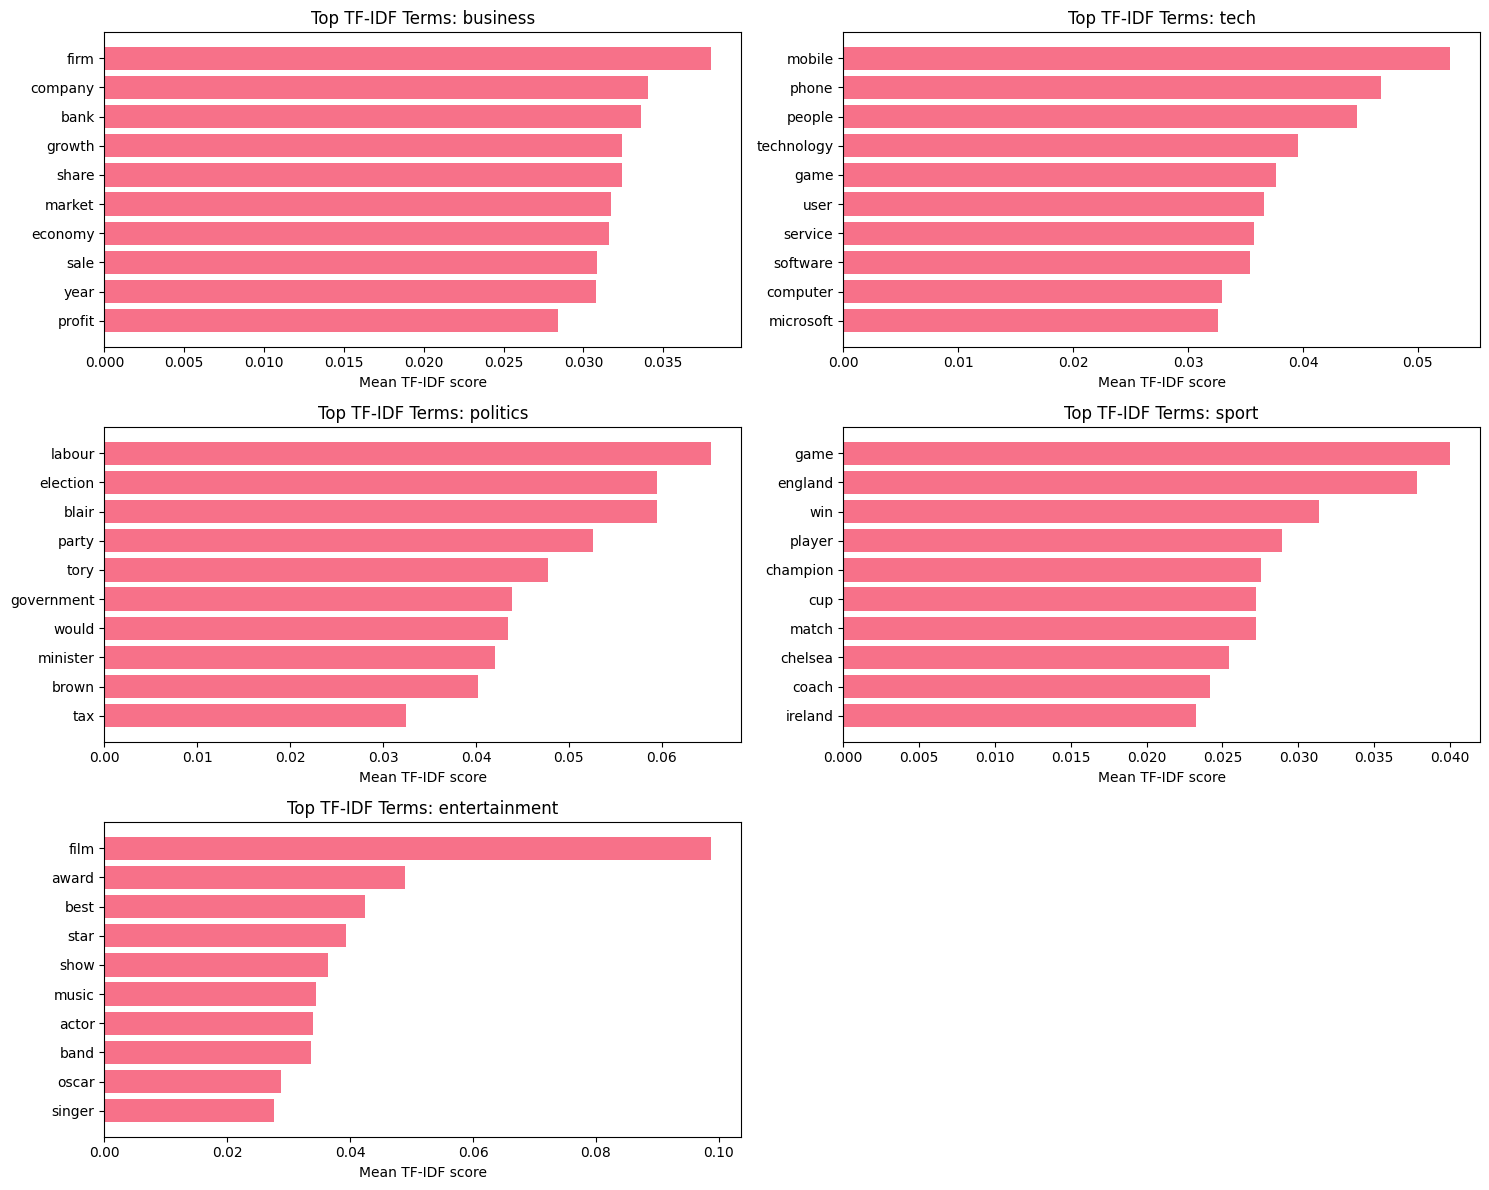

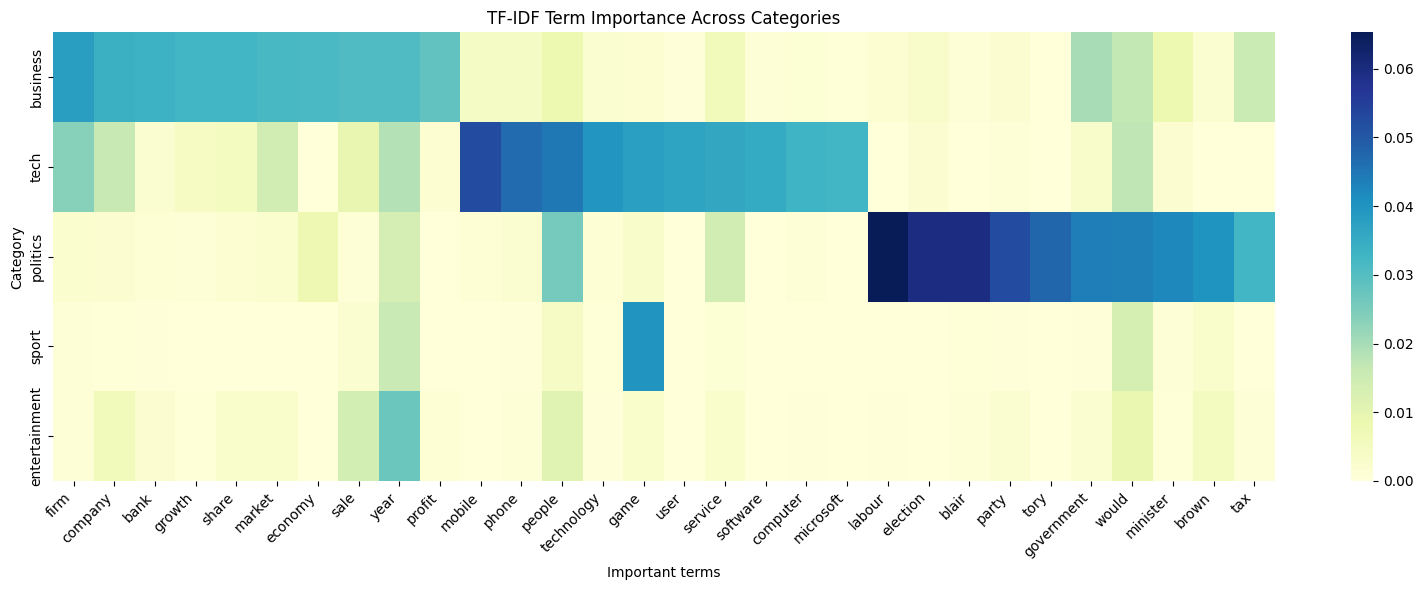

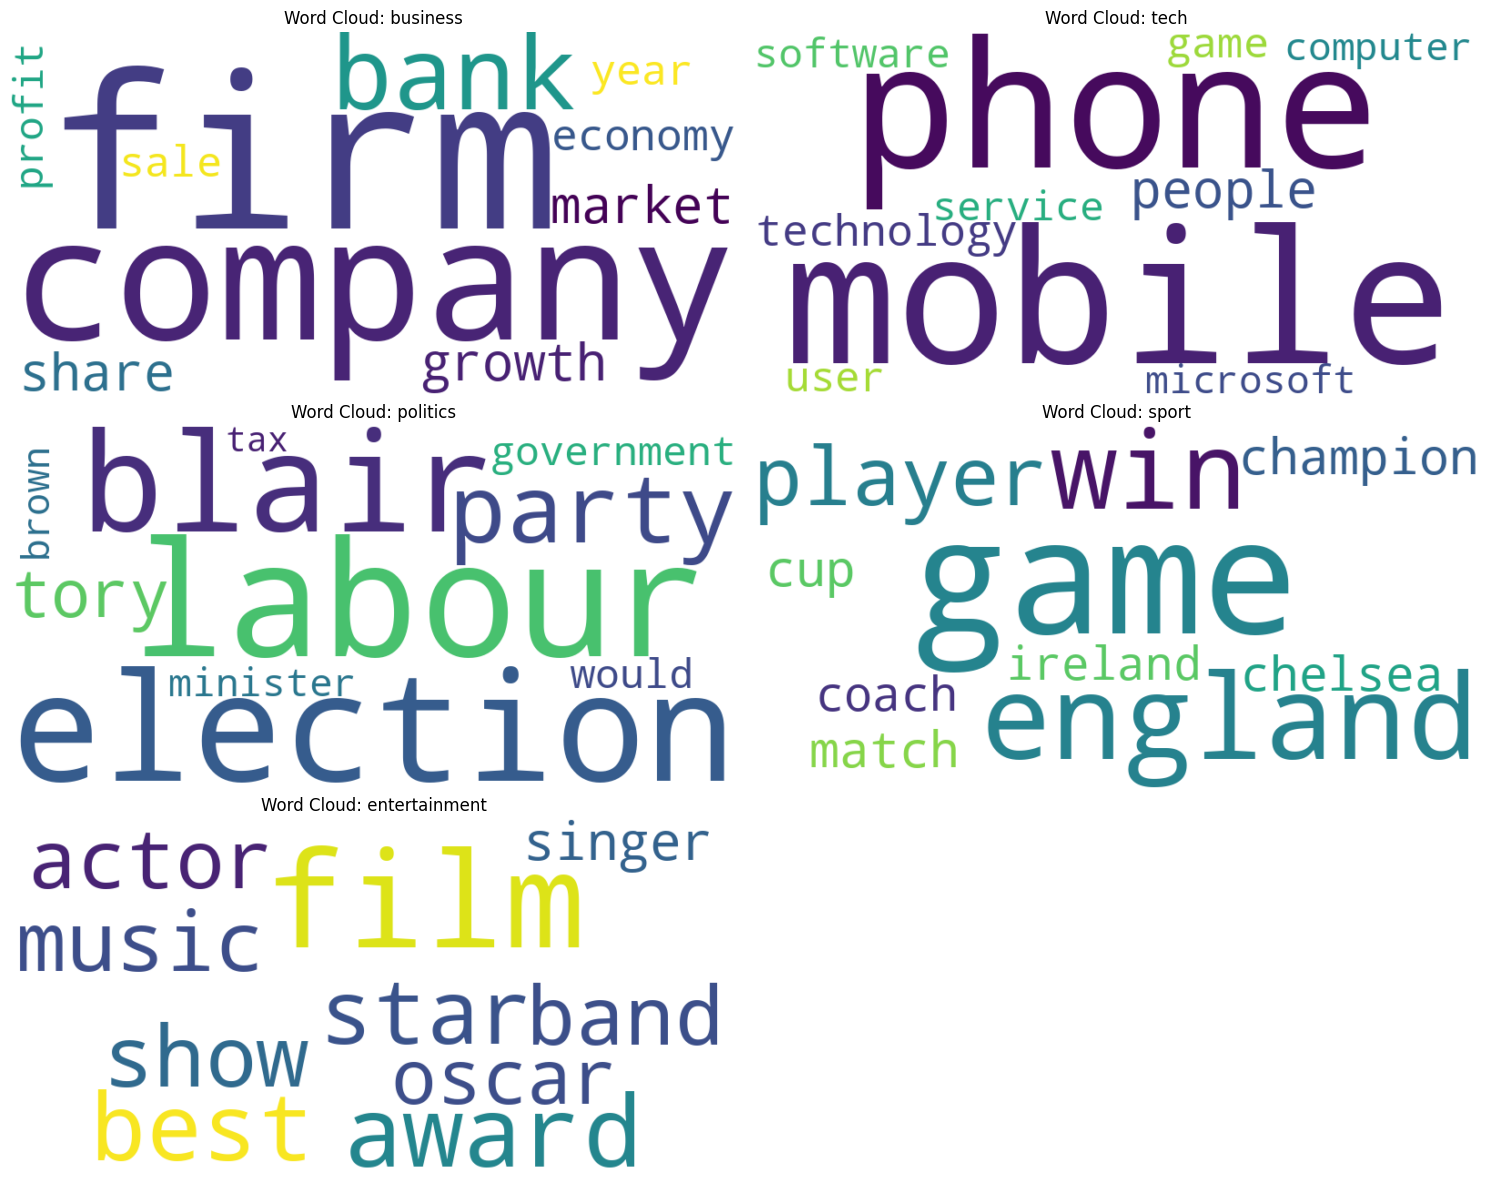

In [9]:
# Analyze the most important TF-IDF terms for each news category.
def get_top_tfidf_terms(category, n_terms=10):
    """
    Return the top TF-IDF terms for one news category.

    The function filters rows for the selected category, calculates the
    mean TF-IDF score for every vocabulary term, and returns the highest
    scoring terms. Higher scores indicate words/phrases that are more
    distinctive for that category.
    """
    category_data = tfidf_df[tfidf_df['category'] == category]
    mean_scores = category_data.drop('category', axis=1).mean().sort_values(ascending=False)
    return mean_scores.head(n_terms)

print("TOP TF-IDF TERMS BY CATEGORY")
print("=" * 50)

categories = df['category'].unique()
category_terms = {}

# Print the top keywords/phrases for each category.
for category in categories:
    top_terms = get_top_tfidf_terms(category, n_terms=10)
    category_terms[category] = top_terms

    print(f"\n{category.upper()}:")
    for term, score in top_terms.items():
        print(f"  {term}: {score:.4f}")

# Convert the top TF-IDF results into a dataframe for easier plotting.
top_term_records = []
for category, terms in category_terms.items():
    for term, score in terms.items():
        top_term_records.append({
            'category': category,
            'term': term,
            'tfidf_score': score
        })

top_terms_df = pd.DataFrame(top_term_records)

# Create bar charts showing the top TF-IDF terms for each category.
n_cols = 2
n_rows = int(np.ceil(len(categories) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, category in zip(axes, categories):
    plot_data = top_terms_df[top_terms_df['category'] == category].sort_values(
        'tfidf_score',
        ascending=True
    )
    ax.barh(plot_data['term'], plot_data['tfidf_score'])
    ax.set_title(f'Top TF-IDF Terms: {category}')
    ax.set_xlabel('Mean TF-IDF score')

# Hide any unused subplot spaces.
for ax in axes[len(categories):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Build a heatmap to compare important terms across categories.
important_terms = list(dict.fromkeys(top_terms_df['term'].tolist()))[:30]
heatmap_rows = []

for category in categories:
    category_data = tfidf_df[tfidf_df['category'] == category]
    heatmap_rows.append(category_data[important_terms].mean())

tfidf_heatmap = pd.DataFrame(heatmap_rows, index=categories)

plt.figure(figsize=(16, 6))
sns.heatmap(tfidf_heatmap, cmap='YlGnBu')
plt.title('TF-IDF Term Importance Across Categories')
plt.xlabel('Important terms')
plt.ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create word clouds so category-specific terms are easy to see visually.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, category in zip(axes, categories):
    frequencies = category_terms[category].to_dict()
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate_from_frequencies(frequencies)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud: {category}')

# Hide any unused subplot spaces.
for ax in axes[len(categories):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Part-of-Speech Analysis

This section uses POS tagging to measure how each category uses nouns, verbs, adjectives, adverbs, and numbers. These patterns help show linguistic differences between news categories beyond simple keyword counts.


In [10]:
def analyze_pos_patterns(text):
    """
    Analyze part-of-speech patterns in one article.

    The function tokenizes the article, applies NLTK POS tagging, counts
    each POS tag, and returns proportions so articles of different lengths
    can be compared fairly.
    """
    if not text or pd.isna(text):
        return {}

    # Tokenize the article and assign a POS tag to each word.
    tokens = word_tokenize(str(text))
    pos_tags = pos_tag(tokens)

    # Count how often each POS tag appears.
    pos_counts = Counter([tag for word, tag in pos_tags])
    total_words = len(pos_tags)

    if total_words == 0:
        return {}

    # Convert counts to proportions so long and short articles can be compared.
    pos_proportions = {
        pos: count / total_words
        for pos, count in pos_counts.items()
    }

    return pos_proportions

print("Analyzing POS patterns...")

# Run POS analysis on every article and keep the category/article ID.
pos_results = []
for idx, row in df.iterrows():
    pos_analysis = analyze_pos_patterns(row['full_text'])
    pos_analysis['category'] = row['category']
    pos_analysis['article_id'] = row['article_id']
    pos_results.append(pos_analysis)

# Convert the POS dictionaries into a dataframe and fill missing tags with 0.
pos_df = pd.DataFrame(pos_results).fillna(0)

print("POS analysis complete!")
print(f"Found {len(pos_df.columns)-2} different POS tags")

# Show a preview of the POS feature table.
print("\nSample POS analysis:")
print(pos_df.head())

Analyzing POS patterns...
POS analysis complete!
Found 43 different POS tags

Sample POS analysis:
        NNP        IN       POS        NN       NNS       VBG        JJ  \
0  0.045181  0.108434  0.003012  0.222892  0.108434  0.024096  0.078313   
1  0.033520  0.134078  0.000000  0.223464  0.067039  0.030726  0.120112   
2  0.021429  0.121429  0.000000  0.194643  0.076786  0.025000  0.076786   
3  0.000000  0.122206  0.000000  0.157973  0.107303  0.022355  0.083458   
4  0.022388  0.119403  0.000000  0.203980  0.074627  0.027363  0.084577   

         DT       VBP       VBN  ...        EX       RBS      NNPS   FW  SYM  \
0  0.063253  0.015060  0.039157  ...  0.000000  0.000000  0.000000  0.0  0.0   
1  0.078212  0.013966  0.027933  ...  0.000000  0.000000  0.000000  0.0  0.0   
2  0.092857  0.016071  0.028571  ...  0.001786  0.005357  0.000000  0.0  0.0   
3  0.062593  0.041729  0.017884  ...  0.001490  0.001490  0.000000  0.0  0.0   
4  0.097015  0.017413  0.027363  ...  0.000000  0.

POS PATTERNS BY CATEGORY

Key POS patterns by category:
                   NN     NNS     NNP    NNPS      VB     VBD     VBG     VBN  \
category                                                                        
business       0.2154  0.0714  0.0273  0.0003  0.0326  0.0399  0.0196  0.0272   
entertainment  0.2352  0.0555  0.0308  0.0002  0.0276  0.0447  0.0189  0.0289   
politics       0.2031  0.0667  0.0180  0.0006  0.0452  0.0452  0.0206  0.0299   
sport          0.2075  0.0460  0.0359  0.0002  0.0397  0.0443  0.0169  0.0243   
tech           0.1879  0.0838  0.0174  0.0003  0.0414  0.0293  0.0236  0.0266   

                  VBP     VBZ      JJ     JJR     JJS      RB     RBR     RBS  \
category                                                                        
business       0.0155  0.0237  0.0894  0.0044  0.0032  0.0266  0.0017  0.0006   
entertainment  0.0174  0.0220  0.0904  0.0024  0.0048  0.0275  0.0009  0.0009   
politics       0.0196  0.0222  0.0881  0.0031  0.001

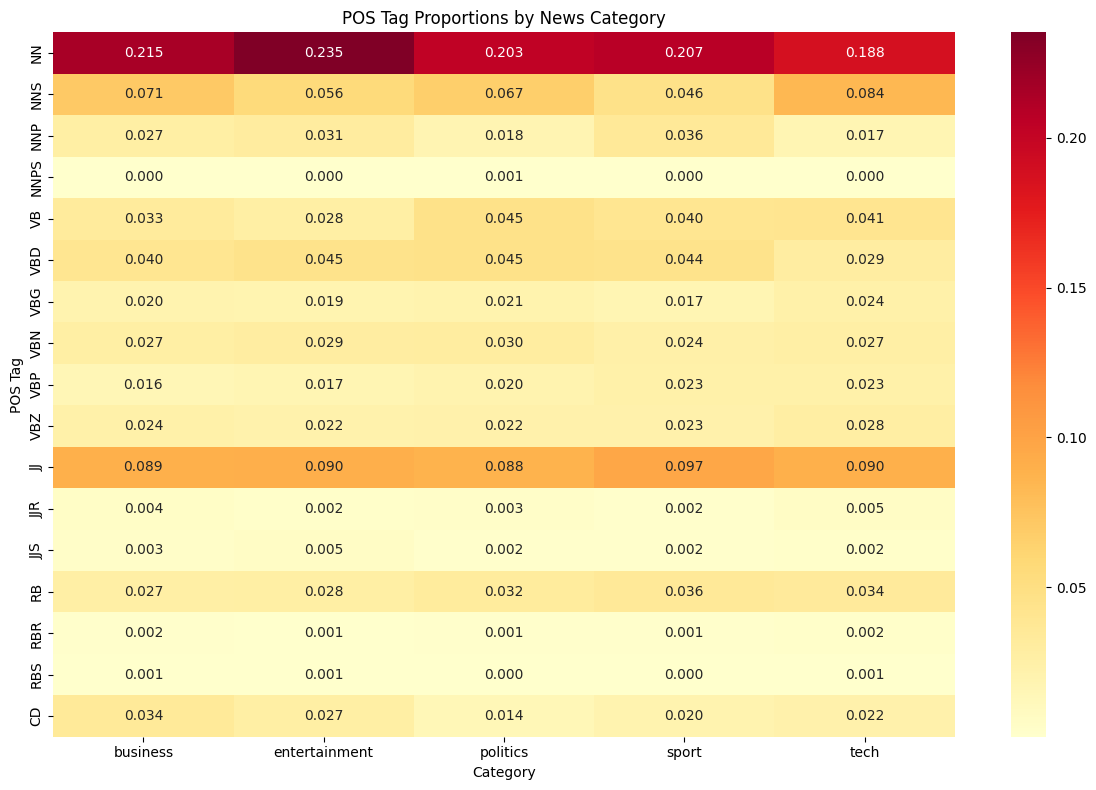


POS interpretation summary:
               noun_proportion  verb_proportion  proper_noun_proportion  \
category                                                                  
business                0.3144           0.1585                  0.0276   
entertainment           0.3217           0.1595                  0.0310   
politics                0.2885           0.1827                  0.0186   
sport                   0.2896           0.1713                  0.0361   
tech                    0.2895           0.1724                  0.0177   

               adjective_proportion  number_proportion  noun_to_verb_ratio  
category                                                                    
business                     0.0970             0.0343              1.9839  
entertainment                0.0976             0.0270              2.0169  
politics                     0.0929             0.0144              1.5786  
sport                        0.1008             0.0198      

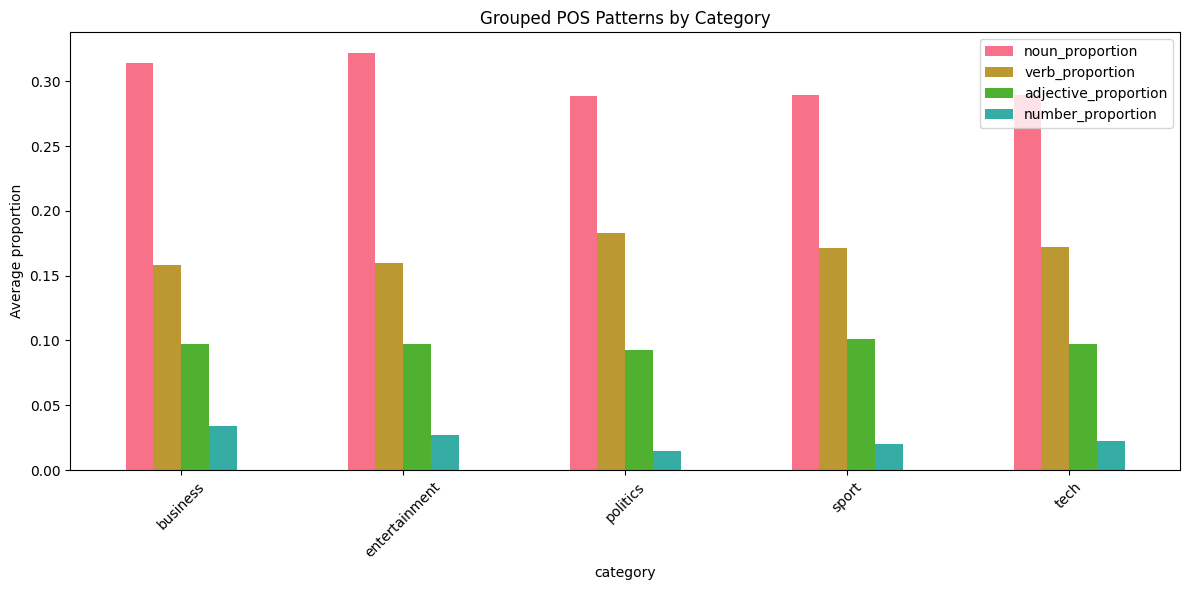

In [11]:
# Analyze average POS tag patterns for each news category.
print("POS PATTERNS BY CATEGORY")
print("=" * 50)

# Group articles by category and calculate the average POS proportions.
pos_by_category = pos_df.groupby('category').mean(numeric_only=True)

# Focus on the most useful POS tags for interpretation.
major_pos = [
    'NN', 'NNS', 'NNP', 'NNPS',
    'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ',
    'JJ', 'JJR', 'JJS',
    'RB', 'RBR', 'RBS',
    'CD'
]

# Keep only POS tags that actually appear in this dataset.
available_pos = [pos for pos in major_pos if pos in pos_by_category.columns]

if available_pos:
    pos_summary = pos_by_category[available_pos]

    print("\nKey POS patterns by category:")
    print(pos_summary.round(4))

    # Heatmap makes it easier to compare POS usage across categories.
    plt.figure(figsize=(12, 8))
    sns.heatmap(pos_summary.T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('POS Tag Proportions by News Category')
    plt.xlabel('Category')
    plt.ylabel('POS Tag')
    plt.tight_layout()
    plt.show()

    # Group related POS tags into broader language categories.
    noun_tags = [tag for tag in ['NN', 'NNS', 'NNP', 'NNPS'] if tag in pos_by_category.columns]
    verb_tags = [tag for tag in ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'] if tag in pos_by_category.columns]
    proper_noun_tags = [tag for tag in ['NNP', 'NNPS'] if tag in pos_by_category.columns]
    adjective_tags = [tag for tag in ['JJ', 'JJR', 'JJS'] if tag in pos_by_category.columns]
    number_tags = [tag for tag in ['CD'] if tag in pos_by_category.columns]

    # Create an interpretation table using broader POS groups.
    pos_interpretation = pd.DataFrame(index=pos_by_category.index)
    pos_interpretation['noun_proportion'] = pos_by_category[noun_tags].sum(axis=1) if noun_tags else 0
    pos_interpretation['verb_proportion'] = pos_by_category[verb_tags].sum(axis=1) if verb_tags else 0
    pos_interpretation['proper_noun_proportion'] = pos_by_category[proper_noun_tags].sum(axis=1) if proper_noun_tags else 0
    pos_interpretation['adjective_proportion'] = pos_by_category[adjective_tags].sum(axis=1) if adjective_tags else 0
    pos_interpretation['number_proportion'] = pos_by_category[number_tags].sum(axis=1) if number_tags else 0
    pos_interpretation['noun_to_verb_ratio'] = (
        pos_interpretation['noun_proportion'] /
        pos_interpretation['verb_proportion'].replace(0, np.nan)
    )

    print("\nPOS interpretation summary:")
    print(pos_interpretation.round(4))

    # Automatically identify the strongest POS patterns.
    highest_proper = pos_interpretation['proper_noun_proportion'].idxmax()
    highest_verb = pos_interpretation['verb_proportion'].idxmax()
    highest_adj = pos_interpretation['adjective_proportion'].idxmax()
    highest_number = pos_interpretation['number_proportion'].idxmax()

    print("\nWritten POS findings:")
    print(f"1. Highest proper noun usage: {highest_proper}")
    print(f"2. Highest action verb usage: {highest_verb}")
    print(f"3. Highest adjective usage: {highest_adj}")
    print(f"4. Highest number/cardinal usage: {highest_number}")

    # Specifically check whether business articles use many numbers.
    if 'business' in pos_interpretation.index:
        business_rank = pos_interpretation['number_proportion'].rank(
            ascending=False,
            method='min'
        ).loc['business']
        print(f"5. Business number usage rank: #{int(business_rank)} out of {len(pos_interpretation)} categories")

    # Plot broader POS groups for easier interpretation.
    pos_interpretation[
        ['noun_proportion', 'verb_proportion', 'adjective_proportion', 'number_proportion']
    ].plot(kind='bar', figsize=(12, 6))

    plt.title('Grouped POS Patterns by Category')
    plt.ylabel('Average proportion')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("No major POS tags found in the analysis. Check your POS tagging implementation.")


## Syntax Parsing and Semantic Analysis

This section uses spaCy dependency parsing to examine sentence structure. It extracts syntactic complexity, noun phrases, subject/object patterns, and simple action patterns such as who did what.


In [12]:
def extract_syntactic_features(text):
    """
    Extract syntactic features with spaCy dependency parsing.

    The function returns sentence counts, token counts, dependency labels,
    noun phrases, verb lemmas, subjects, objects, and simple action patterns
    that approximate who did what in an article.
    """
    if not text or pd.isna(text):
        return {}

    # Process the article with spaCy so we can access sentences, POS tags, and dependencies.
    doc = nlp(str(text))

    # Count the length of each sentence, ignoring punctuation and spaces.
    sentence_lengths = [
        len([token for token in sent if not token.is_punct and not token.is_space])
        for sent in doc.sents
    ]

    # Store all syntactic features in one dictionary.
    features = {
        'num_sentences': len(sentence_lengths),
        'num_tokens': len([token for token in doc if not token.is_space and not token.is_punct]),
        'avg_sentence_length': np.mean(sentence_lengths) if sentence_lengths else 0,
        'dependency_relations': [],
        'noun_phrases': [],
        'verb_phrases': [],
        'subjects': [],
        'objects': [],
        'action_patterns': []
    }

    # Loop through tokens to collect dependency labels, verbs, subjects, objects, and action patterns.
    for token in doc:
        if not token.is_space and not token.is_punct:
            features['dependency_relations'].append(token.dep_)

            if token.pos_ == 'VERB':
                features['verb_phrases'].append(token.lemma_.lower())

            # Subjects help identify "who" is performing or receiving an action.
            if token.dep_ in ['nsubj', 'nsubjpass']:
                features['subjects'].append(token.text.lower())
                verb = token.head

                # Look for objects connected to the same verb.
                objects = [
                    child.text.lower()
                    for child in verb.children
                    if child.dep_ in ['dobj', 'iobj', 'pobj', 'attr', 'dative']
                ]

                features['action_patterns'].append({
                    'subject': token.text.lower(),
                    'verb': verb.lemma_.lower(),
                    'objects': objects
                })

            # Objects help identify what the action is affecting.
            elif token.dep_ in ['dobj', 'iobj', 'pobj', 'attr', 'dative']:
                features['objects'].append(token.text.lower())

    # Extract noun phrases such as "the prime minister" or "financial markets".
    for chunk in doc.noun_chunks:
        features['noun_phrases'].append(chunk.text.lower())

    # Count dependency relation types for later analysis.
    dep_counts = Counter(features['dependency_relations'])
    features['dependency_counts'] = dict(dep_counts)

    return features

print("Performing syntactic analysis...")

# Analyze only a few articles here to keep the notebook fast in Colab.
syntactic_results = []
for idx, row in df.head(5).iterrows():
    features = extract_syntactic_features(row['full_text'][:3000])
    features['category'] = row['category']
    features['article_id'] = row['article_id']
    syntactic_results.append(features)

print("Syntactic analysis complete!")

# Print a readable preview of the syntactic features.
for i, result in enumerate(syntactic_results):
    print(f"\nArticle {i+1} ({result['category']}):")
    print(f"  Sentences: {result['num_sentences']}")
    print(f"  Tokens: {result['num_tokens']}")
    print(f"  Avg sentence length: {result['avg_sentence_length']:.1f}")
    print(f"  Noun phrases: {result['noun_phrases'][:3]}...")
    print(f"  Verb phrases: {result['verb_phrases'][:3]}...")
    print(f"  Subjects: {result['subjects'][:3]}...")
    print(f"  Objects: {result['objects'][:3]}...")

Performing syntactic analysis...
Syntactic analysis complete!

Article 1 (business):
  Sentences: 15
  Tokens: 322
  Avg sentence length: 21.5
  Noun phrases: ['worldcom ex-boss launches defence lawyers', 'former worldcom chief bernie ebbers', 'fraud']...
  Verb phrases: ['defend', 'launch', 'defend']...
  Subjects: ['lawyers', 'ex', 'boss']...
  Objects: ['ebbers', 'fraud', 'worldcom']...

Article 2 (business):
  Sentences: 15
  Tokens: 342
  Avg sentence length: 22.8
  Noun phrases: ['german business confidence slides german business confidence', 'february', 'knocking hopes']...
  Verb phrases: ['fall', 'slide', 'fall']...
  Subjects: ['confidence', 'fell', 'hopes']...
  Objects: ['february', 'confidence', 'confidence']...

Article 3 (business):
  Sentences: 22
  Tokens: 498
  Avg sentence length: 22.6
  Noun phrases: ['bbc poll', 'economic gloom citizens', 'a majority']...
  Verb phrases: ['indicate', 'survey', 'indicate']...
  Subjects: ['poll', 'citizens', 'economy']...
  Objects:

Sample sentence: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.

Dependency Parse Visualization:



SYNTACTIC COMPLEXITY BY CATEGORY

Average syntactic features by category:
               article_id  num_sentences  num_tokens  avg_sentence_length  \
category                                                                    
business           1207.8           18.0       401.0                22.29   
entertainment      1067.0           14.8       321.2                23.88   
politics           1731.0           14.6       309.6                21.20   
sport               955.2           18.0       336.6                18.53   
tech               1317.2           20.0       419.4                20.94   

               noun_phrase_count  verb_count  subject_count  object_count  
category                                                                   
business                   102.2        46.6           36.0          65.0  
entertainment               89.8        39.6           26.2          58.0  
politics                    83.0        40.0           32.2          49.8  
sport

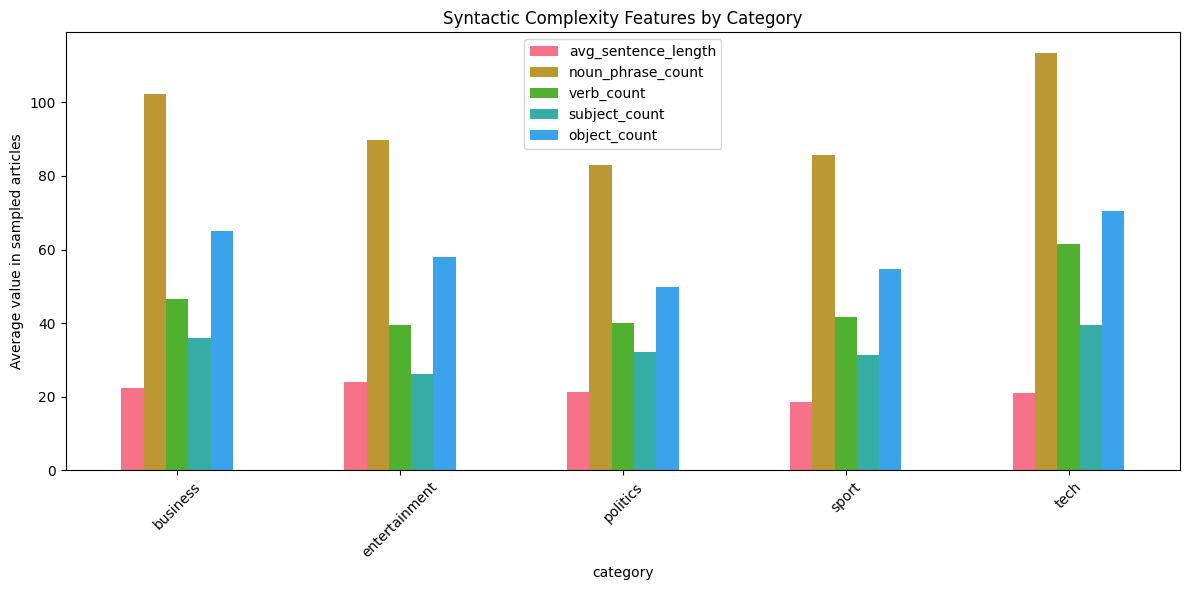

In [13]:
# Visualize dependency parsing for one sample sentence.
from spacy import displacy

# Use the first sentence from the first article so the dependency graph is readable.
sentences = sent_tokenize(df.iloc[0]['content'])
sample_sentence = sentences[0] if sentences else df.iloc[0]['content'][:500]
print(f"Sample sentence: {sample_sentence}")

# Process the sample sentence with spaCy.
doc = nlp(sample_sentence)

print("\nDependency Parse Visualization:")

# Try to show the visual dependency tree in the notebook.
# If that fails, print the dependency relationships as text instead.
try:
    displacy.render(doc, style="dep", jupyter=True)
except Exception:
    print("\nDependency Relations:")
    for token in doc:
        if not token.is_space and not token.is_punct:
            print(f"  {token.text} --> {token.dep_} --> {token.head.text}")

# Compare syntax patterns across a small sample from each category.
print("\nSYNTACTIC COMPLEXITY BY CATEGORY")
print("=" * 50)

# Use five articles per category to keep this section fast in Colab.
syntax_sample = df.groupby('category', group_keys=False).head(5)

syntax_rows = []
dependency_by_category = defaultdict(Counter)
action_pattern_rows = []

for _, row in syntax_sample.iterrows():
    # Limit each article to 3000 characters for speed.
    features = extract_syntactic_features(row['full_text'][:3000])

    # Store summary features for this article.
    syntax_rows.append({
        'category': row['category'],
        'article_id': row['article_id'],
        'num_sentences': features.get('num_sentences', 0),
        'num_tokens': features.get('num_tokens', 0),
        'avg_sentence_length': features.get('avg_sentence_length', 0),
        'noun_phrase_count': len(features.get('noun_phrases', [])),
        'verb_count': len(features.get('verb_phrases', [])),
        'subject_count': len(features.get('subjects', [])),
        'object_count': len(features.get('objects', []))
    })

    # Track dependency relation counts by category.
    dependency_by_category[row['category']].update(features.get('dependency_counts', {}))

    # Save a few subject-verb-object style action patterns.
    for pattern in features.get('action_patterns', [])[:5]:
        action_pattern_rows.append({
            'category': row['category'],
            'subject': pattern['subject'],
            'verb': pattern['verb'],
            'objects': ', '.join(pattern['objects']) if pattern['objects'] else '(none)'
        })

# Convert syntactic feature rows into a dataframe.
syntax_df = pd.DataFrame(syntax_rows)

# Average the syntactic features for each category.
syntax_summary = syntax_df.groupby('category').mean(numeric_only=True).round(2)

print("\nAverage syntactic features by category:")
print(syntax_summary)

# Show the most common dependency relations in each category.
print("\nMost common dependency relations by category:")
for category, counter in dependency_by_category.items():
    print(f"\n{category}:")
    for dep, count in counter.most_common(5):
        print(f"  {dep}: {count}")

# Display example action patterns, if any were found.
if action_pattern_rows:
    action_patterns_df = pd.DataFrame(action_pattern_rows)
    print("\nSample action patterns (who did what):")
    print(action_patterns_df.head(10))
else:
    action_patterns_df = pd.DataFrame(columns=['category', 'subject', 'verb', 'objects'])
    print("\nNo action patterns extracted from the sample.")

# Visualize syntactic complexity features by category.
syntax_summary[
    ['avg_sentence_length', 'noun_phrase_count', 'verb_count', 'subject_count', 'object_count']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Syntactic Complexity Features by Category')
plt.ylabel('Average value in sampled articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sentiment and Emotion Analysis

This section applies VADER sentiment analysis to headlines, article bodies, and combined article text. The goal is to compare emotional tone across categories and create sentiment features for classification.


In [14]:
# Initialize VADER, a sentiment analyzer that works well for short text and news-style writing.
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """
    Analyze sentiment with VADER.

    Returns the compound sentiment score, positive/neutral/negative scores,
    and a readable label: positive, negative, or neutral.
    """
    if not text or pd.isna(text):
        return {'compound': 0, 'pos': 0, 'neu': 1, 'neg': 0, 'sentiment_label': 'neutral'}

    # Get VADER sentiment scores for the text.
    scores = sia.polarity_scores(str(text))

    # Convert the compound score into a simple sentiment label.
    if scores['compound'] >= 0.05:
        scores['sentiment_label'] = 'positive'
    elif scores['compound'] <= -0.05:
        scores['sentiment_label'] = 'negative'
    else:
        scores['sentiment_label'] = 'neutral'

    return scores

print("Analyzing sentiment...")

# Analyze title, content, and full article sentiment for every article.
sentiment_results = []
for idx, row in df.iterrows():
    title_sentiment = analyze_sentiment(row['title'])
    content_sentiment = analyze_sentiment(row['content'])
    full_sentiment = analyze_sentiment(row['full_text'])

    result = {
        'article_id': row['article_id'],
        'category': row['category'],
        'title_sentiment': title_sentiment['compound'],
        'title_label': title_sentiment['sentiment_label'],
        'content_sentiment': content_sentiment['compound'],
        'content_label': content_sentiment['sentiment_label'],
        'full_sentiment': full_sentiment['compound'],
        'full_label': full_sentiment['sentiment_label'],
        'pos_score': full_sentiment['pos'],
        'neu_score': full_sentiment['neu'],
        'neg_score': full_sentiment['neg']
    }

    sentiment_results.append(result)

# Convert the sentiment results into a dataframe for analysis and plotting.
sentiment_df = pd.DataFrame(sentiment_results)

print("Sentiment analysis complete!")
print(f"Analyzed {len(sentiment_df)} articles")

# Preview the sentiment results.
print("\nSample sentiment results:")
print(sentiment_df[['category', 'full_sentiment', 'full_label']].head())

Analyzing sentiment...
Sentiment analysis complete!
Analyzed 1490 articles

Sample sentiment results:
   category  full_sentiment full_label
0  business         -0.9741   negative
1  business          0.8948   positive
2  business         -0.9454   negative
3      tech          0.9554   positive
4  business         -0.9383   negative


SENTIMENT ANALYSIS BY CATEGORY

Sentiment statistics by category:
              full_sentiment                         pos_score neu_score  \
                        mean     std     min     max      mean      mean   
category                                                                   
business              0.2312  0.8450 -0.9985  0.9995    0.0927    0.8367   
entertainment         0.5920  0.6960 -0.9978  0.9999    0.1355    0.8108   
politics              0.0376  0.8833 -0.9985  0.9999    0.0941    0.8186   
sport                 0.5493  0.7352 -0.9970  0.9996    0.1342    0.7946   
tech                  0.5153  0.7651 -0.9992  0.9993    0.0894    0.8597   

              neg_score  
                   mean  
category                 
business         0.0705  
entertainment    0.0537  
politics         0.0874  
sport            0.0711  
tech             0.0509  

Sentiment distribution (%) by category:
full_label     negative  neutral  positive
category                         

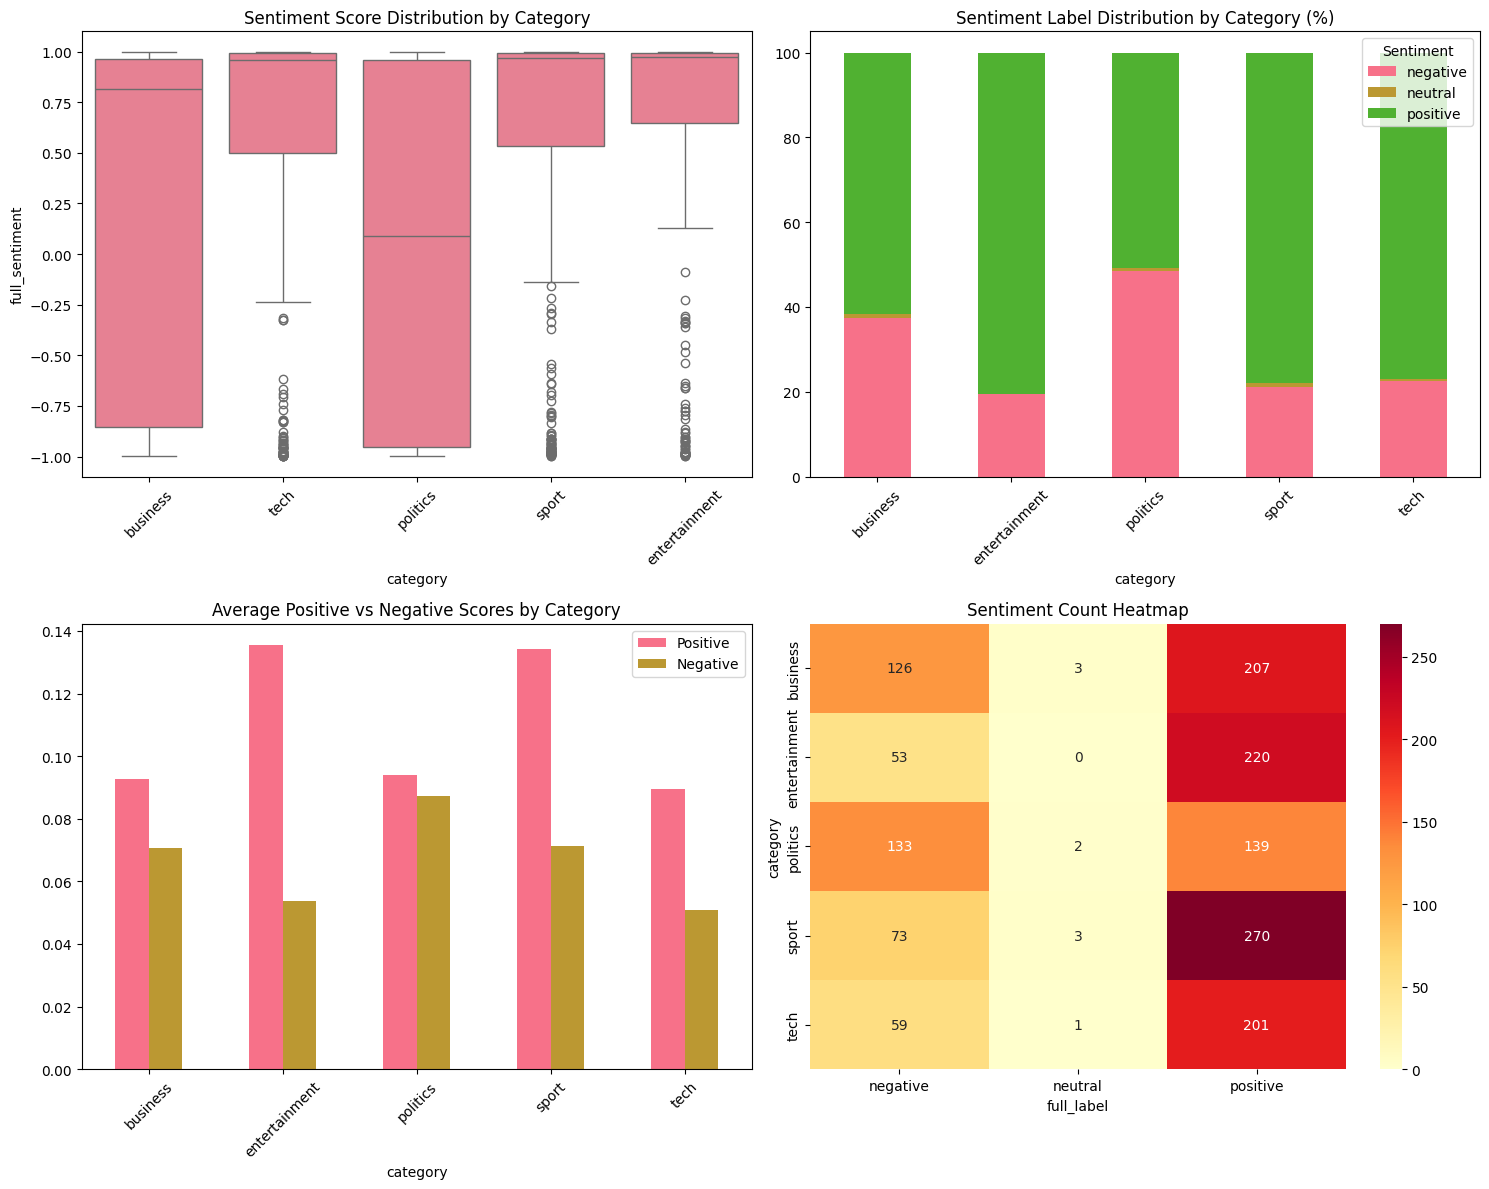


Written sentiment findings:
1. Most positive category by average compound score: entertainment (0.5920)
2. Most negative category by average compound score: politics (0.0376)
3. Category with the most sentiment variation: politics (0.8833 std)
4. Title/content sentiment labels differ in 54.1% of articles.
5. Sentiment can be used as a classification feature; Module 7 uses scaled compound, positive, neutral, and negative scores.

Average content-minus-title sentiment difference by category:
category
sport            0.4987
tech             0.4699
entertainment    0.4240
business         0.2070
politics         0.1394
Name: title_content_difference, dtype: float64


In [15]:
# Analyze sentiment patterns across news categories.
print("SENTIMENT ANALYSIS BY CATEGORY")
print("=" * 50)

# Calculate summary sentiment statistics for each category.
sentiment_by_category = sentiment_df.groupby('category').agg({
    'full_sentiment': ['mean', 'std', 'min', 'max'],
    'pos_score': 'mean',
    'neu_score': 'mean',
    'neg_score': 'mean'
}).round(4)

print("\nSentiment statistics by category:")
print(sentiment_by_category)

# Count how many positive, negative, and neutral articles appear in each category.
sentiment_dist = sentiment_df.groupby(['category', 'full_label']).size().unstack(fill_value=0)
sentiment_dist_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

print("\nSentiment distribution (%) by category:")
print(sentiment_dist_pct.round(2))

# Create four sentiment visualizations.
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Show the spread of compound sentiment scores by category.
sns.boxplot(data=sentiment_df, x='category', y='full_sentiment', ax=axes[0,0])
axes[0,0].set_title('Sentiment Score Distribution by Category')
axes[0,0].tick_params(axis='x', rotation=45)

# Show the percentage of positive, neutral, and negative articles per category.
sentiment_dist_pct.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Sentiment Label Distribution by Category (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Sentiment')

# Compare average positive and negative scores.
category_means = sentiment_df.groupby('category')[['pos_score', 'neg_score']].mean()
category_means.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Positive vs Negative Scores by Category')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Positive', 'Negative'])

# Show sentiment label counts in heatmap form.
sentiment_pivot = sentiment_df.pivot_table(
    values='full_sentiment',
    index='category',
    columns='full_label',
    aggfunc='count',
    fill_value=0
)
sns.heatmap(sentiment_pivot, annot=True, fmt='d', ax=axes[1,1], cmap='YlOrRd')
axes[1,1].set_title('Sentiment Count Heatmap')

plt.tight_layout()
plt.show()

# Generate written findings that answer the sentiment analysis questions.
mean_sentiment = sentiment_df.groupby('category')['full_sentiment'].mean().sort_values(ascending=False)
sentiment_variability = sentiment_df.groupby('category')['full_sentiment'].std().sort_values(ascending=False)

# Compare article body sentiment against title sentiment.
title_content_gap = sentiment_df.assign(
    title_content_difference=sentiment_df['content_sentiment'] - sentiment_df['title_sentiment']
).groupby('category')['title_content_difference'].mean().sort_values(ascending=False)

# Measure how often title sentiment and content sentiment disagree.
label_mismatch_rate = (sentiment_df['title_label'] != sentiment_df['content_label']).mean()

print("\nWritten sentiment findings:")
print(f"1. Most positive category by average compound score: {mean_sentiment.index[0]} ({mean_sentiment.iloc[0]:.4f})")
print(f"2. Most negative category by average compound score: {mean_sentiment.index[-1]} ({mean_sentiment.iloc[-1]:.4f})")
print(f"3. Category with the most sentiment variation: {sentiment_variability.index[0]} ({sentiment_variability.iloc[0]:.4f} std)")
print(f"4. Title/content sentiment labels differ in {label_mismatch_rate:.1%} of articles.")
print("5. Sentiment can be used as a classification feature; Module 7 uses scaled compound, positive, neutral, and negative scores.")

print("\nAverage content-minus-title sentiment difference by category:")
print(title_content_gap.round(4))

## Text Classification System

This section builds the main NewsBot classifier. The model combines TF-IDF text features with scaled sentiment and length features, compares several algorithms, tunes Logistic Regression, and selects the best-performing model.


In [16]:
# Prepare the feature matrix used for article classification.
print("Preparing features for classification...")

# Keep TF-IDF as a sparse matrix to save memory and run faster in Colab.
X_tfidf = tfidf_matrix

# Add sentiment features from the VADER analysis.
# Compound sentiment ranges from -1 to 1, so scale it to 0 to 1 for Naive Bayes.
compound_scaled = ((sentiment_df['full_sentiment'] + 1) / 2).values.reshape(-1, 1)

sentiment_features = np.hstack([
    compound_scaled,
    sentiment_df[['pos_score', 'neu_score', 'neg_score']].values
])

# Add simple text-length features.
length_features = np.array([
    df['full_text'].str.len(),
    df['full_text'].str.split().str.len(),
    df['title'].str.len(),
]).T.astype(float)

# Scale length features so they do not overpower TF-IDF scores.
length_feature_max = np.maximum(length_features.max(axis=0), 1)
length_features = length_features / length_feature_max

# Combine TF-IDF, sentiment, and length features into one sparse feature matrix.
extra_features = csr_matrix(np.hstack([sentiment_features, length_features]))
X_combined = hstack([X_tfidf, extra_features]).tocsr()

# Store the category labels as the target variable.
y = df['category'].values

print("Feature matrix prepared!")
print(f"Feature matrix shape: {X_combined.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

# Split the data into training and testing sets.
# stratify=y keeps the category distribution similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nData split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

Preparing features for classification...
Feature matrix prepared!
Feature matrix shape: (1490, 5007)
Number of classes: 5
Classes: ['business' 'entertainment' 'politics' 'sport' 'tech']

Data split:
  Training set: 1192 samples
  Test set: 298 samples


In [17]:
# Train and compare multiple classifiers for news category prediction.
print("Training multiple improved classifiers...")

# Tune Logistic Regression by testing several C values.
# C controls regularization strength; higher C means less regularization.
print("\nTuning Logistic Regression C value...")
c_values = [0.5, 1.0, 2.0, 4.0]
tuning_results = []

for c in c_values:
    candidate = LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='liblinear',
        C=c,
        class_weight='balanced'
    )

    # Use 3-fold cross-validation to estimate performance more reliably.
    scores = cross_val_score(candidate, X_train, y_train, cv=3, scoring='accuracy')

    tuning_results.append({
        'C': c,
        'CV Mean': scores.mean(),
        'CV Std': scores.std()
    })

    print(f"  C={c}: CV accuracy={scores.mean():.4f}")

# Select the C value with the highest average cross-validation accuracy.
tuning_df = pd.DataFrame(tuning_results)
best_c = tuning_df.loc[tuning_df['CV Mean'].idxmax(), 'C']
print(f"Best C value selected: {best_c}")

# Compare a baseline model with stronger text-classification models.
classifiers = {
    'Baseline Multinomial NB': MultinomialNB(alpha=0.5),
    'Improved Complement NB': ComplementNB(alpha=0.5),
    'Tuned Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='liblinear',
        C=best_c,
        class_weight='balanced'
    ),
    'Fast Linear SVM': LinearSVC(
        random_state=42,
        C=1.0,
        class_weight='balanced'
    )
}

# Store model scores and trained model objects.
results = {}
trained_models = {}

for name, classifier in classifiers.items():
    print(f"\nTraining {name}...")

    # Train the classifier and make predictions on the test set.
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    # Calculate test accuracy.
    accuracy = accuracy_score(y_test, y_pred)

    # Cross-validation gives another performance estimate using only training data.
    cv_scores = cross_val_score(classifier, X_train, y_train, cv=3, scoring='accuracy')

    # Some models provide probabilities, while LinearSVC does not.
    y_pred_proba = classifier.predict_proba(X_test) if hasattr(classifier, 'predict_proba') else None

    # Save all useful outputs for later evaluation.
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    trained_models[name] = classifier

    print(f"  Test accuracy: {accuracy:.4f}")
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Build a comparison table for all trained classifiers.
print("\nCLASSIFIER COMPARISON")
print("=" * 50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
}).sort_values(by='Test Accuracy', ascending=False)

print(comparison_df.round(4))

# Select the best model based on test accuracy.
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")

Training multiple improved classifiers...

Tuning Logistic Regression C value...
  C=0.5: CV accuracy=0.9312
  C=1.0: CV accuracy=0.9513
  C=2.0: CV accuracy=0.9580
  C=4.0: CV accuracy=0.9614
Best C value selected: 4.0

Training Baseline Multinomial NB...
  Test accuracy: 0.9765
  CV Score: 0.9656 (+/- 0.0104)

Training Improved Complement NB...
  Test accuracy: 0.9698
  CV Score: 0.9664 (+/- 0.0086)

Training Tuned Logistic Regression...
  Test accuracy: 0.9832
  CV Score: 0.9614 (+/- 0.0262)

Training Fast Linear SVM...
  Test accuracy: 0.9866
  CV Score: 0.9706 (+/- 0.0133)

CLASSIFIER COMPARISON
                       Model  Test Accuracy  CV Mean  CV Std
3            Fast Linear SVM         0.9866   0.9706  0.0066
2  Tuned Logistic Regression         0.9832   0.9614  0.0131
0    Baseline Multinomial NB         0.9765   0.9656  0.0052
1     Improved Complement NB         0.9698   0.9664  0.0043

Best performing model: Fast Linear SVM


DETAILED EVALUATION: Fast Linear SVM

Classification Report:
               precision    recall  f1-score   support

     business       0.99      1.00      0.99        67
entertainment       0.98      1.00      0.99        55
     politics       1.00      0.96      0.98        55
        sport       1.00      1.00      1.00        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.99       298
    macro avg       0.99      0.99      0.99       298
 weighted avg       0.99      0.99      0.99       298



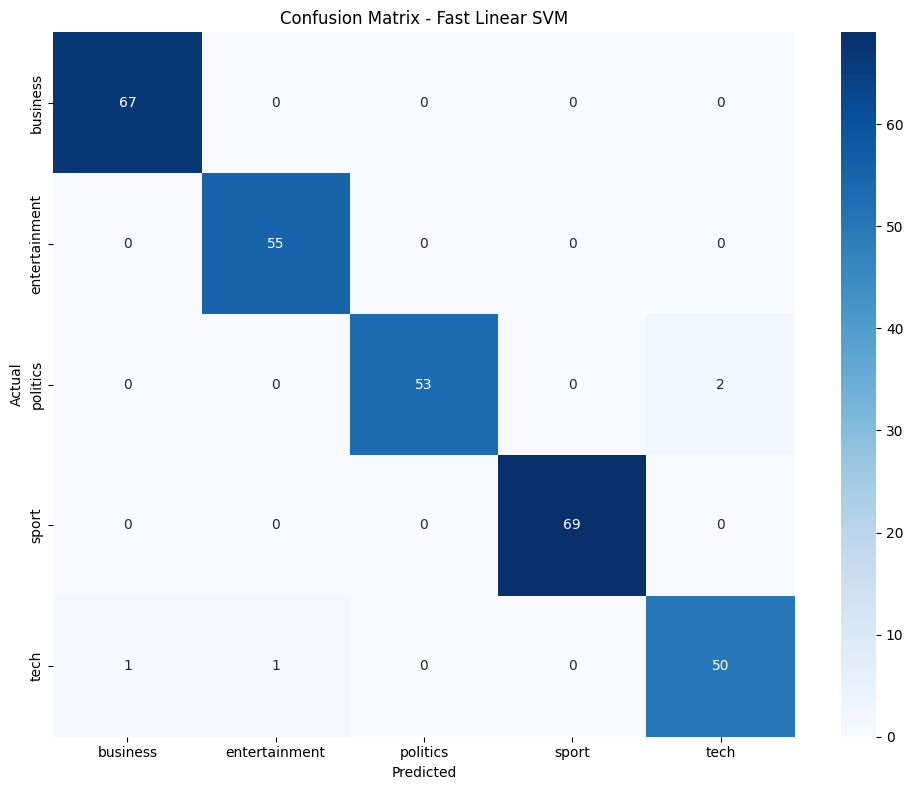


Top Features by Category:

business:
  firm: 1.6968
  bank: 1.4233
  company: 1.2326
  economic: 1.2242
  business: 1.1882
  investment: 1.1865
  share: 1.0513
  economy: 1.0475
  market: 0.9856
  profit: 0.9449

entertainment:
  film: 2.0182
  show: 1.7337
  singer: 1.4416
  star: 1.4215
  album: 1.3225
  actor: 1.3169
  music: 1.3065
  band: 1.3052
  gallery: 1.0750
  musician: 1.0559

politics:
  blair: 1.5122
  party: 1.4456
  labour: 1.3666
  rail: 1.0825
  straw: 1.0491
  lord: 1.0482
  minister: 1.0429
  secretary: 1.0023
  child: 0.9726
  election: 0.9652

sport:
  match: 1.1147
  coach: 1.0731
  champion: 1.0656
  cup: 0.9355
  chelsea: 0.9006
  rugby: 0.8546
  player: 0.8238
  england: 0.8232
  olympic: 0.8129
  season: 0.8087

tech:
  computer: 1.5107
  game: 1.3812
  software: 1.2745
  technology: 1.2293
  user: 1.1921
  net: 1.1047
  mobile: 1.0033
  online: 0.9942
  blog: 0.9846
  speed: 0.9814

CLASSIFIER IMPROVEMENT SUMMARY
- Used sparse TF-IDF features for better spee

In [18]:
# Retrieve the best trained model and its test-set predictions.
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

print(f"DETAILED EVALUATION: {best_model_name}")
print("=" * 60)

# Show precision, recall, F1-score, and accuracy for each category.
print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

# Create a confusion matrix to show correct and incorrect category predictions.
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# If the model has coefficients, print the strongest features for each category.
if hasattr(best_model, 'coef_'):
    print("\nTop Features by Category:")

    # Add names for the extra sentiment and length features added after TF-IDF.
    feature_names_extended = list(feature_names) + [
        'compound_sentiment_scaled',
        'pos_score',
        'neu_score',
        'neg_score',
        'char_length_scaled',
        'word_count_scaled',
        'title_length_scaled'
    ]

    classes = best_model.classes_
    coefficients = best_model.coef_

    # For each category, find the features with the largest positive coefficients.
    for i, class_name in enumerate(classes):
        top_indices = np.argsort(coefficients[i])[-10:]

        print(f"\n{class_name}:")
        for idx in reversed(top_indices):
            if idx < len(feature_names_extended):
                print(f"  {feature_names_extended[idx]}: {coefficients[i][idx]:.4f}")

else:
    print("\nFeature importance is skipped because this model does not expose coefficients.")

# Summarize how the classifier was improved beyond the starter template.
print("\nCLASSIFIER IMPROVEMENT SUMMARY")
print("- Used sparse TF-IDF features for better speed and memory efficiency in Colab.")
print("- Added scaled sentiment and length features to enrich the text representation.")
print("- Tuned Logistic Regression with cross-validation over multiple C values.")
print("- Added Complement Naive Bayes, which is often stronger for text classification.")
print("- Replaced slow default SVC with fast Linear SVM for TF-IDF text data.")
print("- Used stratified train/test split and class_weight='balanced' where supported.")

## Named Entity Recognition

This section extracts people, organizations, locations, dates, money amounts, and other named entities using spaCy. Entity analysis helps turn raw articles into media-monitoring intelligence about who and what appears in the news.


In [19]:
def extract_entities(text):
    """
    Extract named entities using spaCy.

    Returns a list of dictionaries containing the entity text, label,
    character span, and a plain-English label description.
    """
    if not text or pd.isna(text):
        return []

    # Process the article text with spaCy's NLP pipeline.
    doc = nlp(str(text))

    entities = []

    # Store each detected entity with its label and location in the text.
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
            'description': spacy.explain(ent.label_)
        })

    return entities

print("Extracting named entities...")

# Store both article-level entity lists and one combined entity table.
all_entities = []
article_entities = []

for idx, row in df.iterrows():
    entities = extract_entities(row['full_text'])

    # Keep the full entity list for each individual article.
    article_entities.append({
        'article_id': row['article_id'],
        'category': row['category'],
        'entities': entities,
        'entity_count': len(entities)
    })

    # Add article information to each entity so we can analyze entities by category.
    for entity in entities:
        entity['article_id'] = row['article_id']
        entity['category'] = row['category']
        all_entities.append(entity)

print("Entity extraction complete!")
print(f"Total entities found: {len(all_entities)}")
print(f"Articles processed: {len(article_entities)}")

# Convert all extracted entities into a dataframe for analysis.
entities_df = pd.DataFrame(all_entities)

# Preview the entity types and examples if any were found.
if not entities_df.empty:
    print(f"\nEntity types found: {entities_df['label'].unique()}")
    print("\nSample entities:")
    print(entities_df[['text', 'label', 'category']].head(10))
else:
    print("No entities found. This might happen with very short sample texts.")

Extracting named entities...
Entity extraction complete!
Total entities found: 43735
Articles processed: 1490

Entity types found: ['ORG' 'PERSON' 'ORDINAL' 'GPE' 'DATE' 'MONEY' 'NORP' 'LOC' 'CARDINAL'
 'PERCENT' 'TIME' 'WORK_OF_ART' 'EVENT' 'QUANTITY' 'FAC' 'PRODUCT'
 'LANGUAGE' 'LAW']

Sample entities:
                                                text    label  category
0  Worldcom Ex-Boss Launches Defence Lawyers Defe...      ORG  business
1                                      Bernie Ebbers   PERSON  business
2                                              first  ORDINAL  business
3                                     cynthia cooper   PERSON  business
4                                                 us      GPE  business
5                                               2002     DATE  business
6                                              5.7bn    MONEY  business
7                                           new york      GPE  business
8                                          wed

NAMED ENTITY ANALYSIS

Entity type distribution:
label
DATE           8933
PERSON         8634
CARDINAL       6282
GPE            5672
ORG            4942
NORP           2782
MONEY          1830
ORDINAL        1662
PERCENT        1304
TIME            593
LOC             504
QUANTITY        201
FAC             100
PRODUCT          90
LANGUAGE         62
EVENT            62
WORK_OF_ART      46
LAW              36
Name: count, dtype: int64

Entity types by news category:
label          CARDINAL  DATE  EVENT  FAC   GPE  LANGUAGE  LAW  LOC  MONEY  \
category                                                                     
business           1059  2474      4   15  1589         1   15  166    945   
entertainment      1128  1754     13   16   806         9    4   64    389   
politics            834  1365     22   24   946        10    4  120    235   
sport              1839  2012     19   42  1550        12    7   34     44   
tech               1422  1328      4    3   781        30  

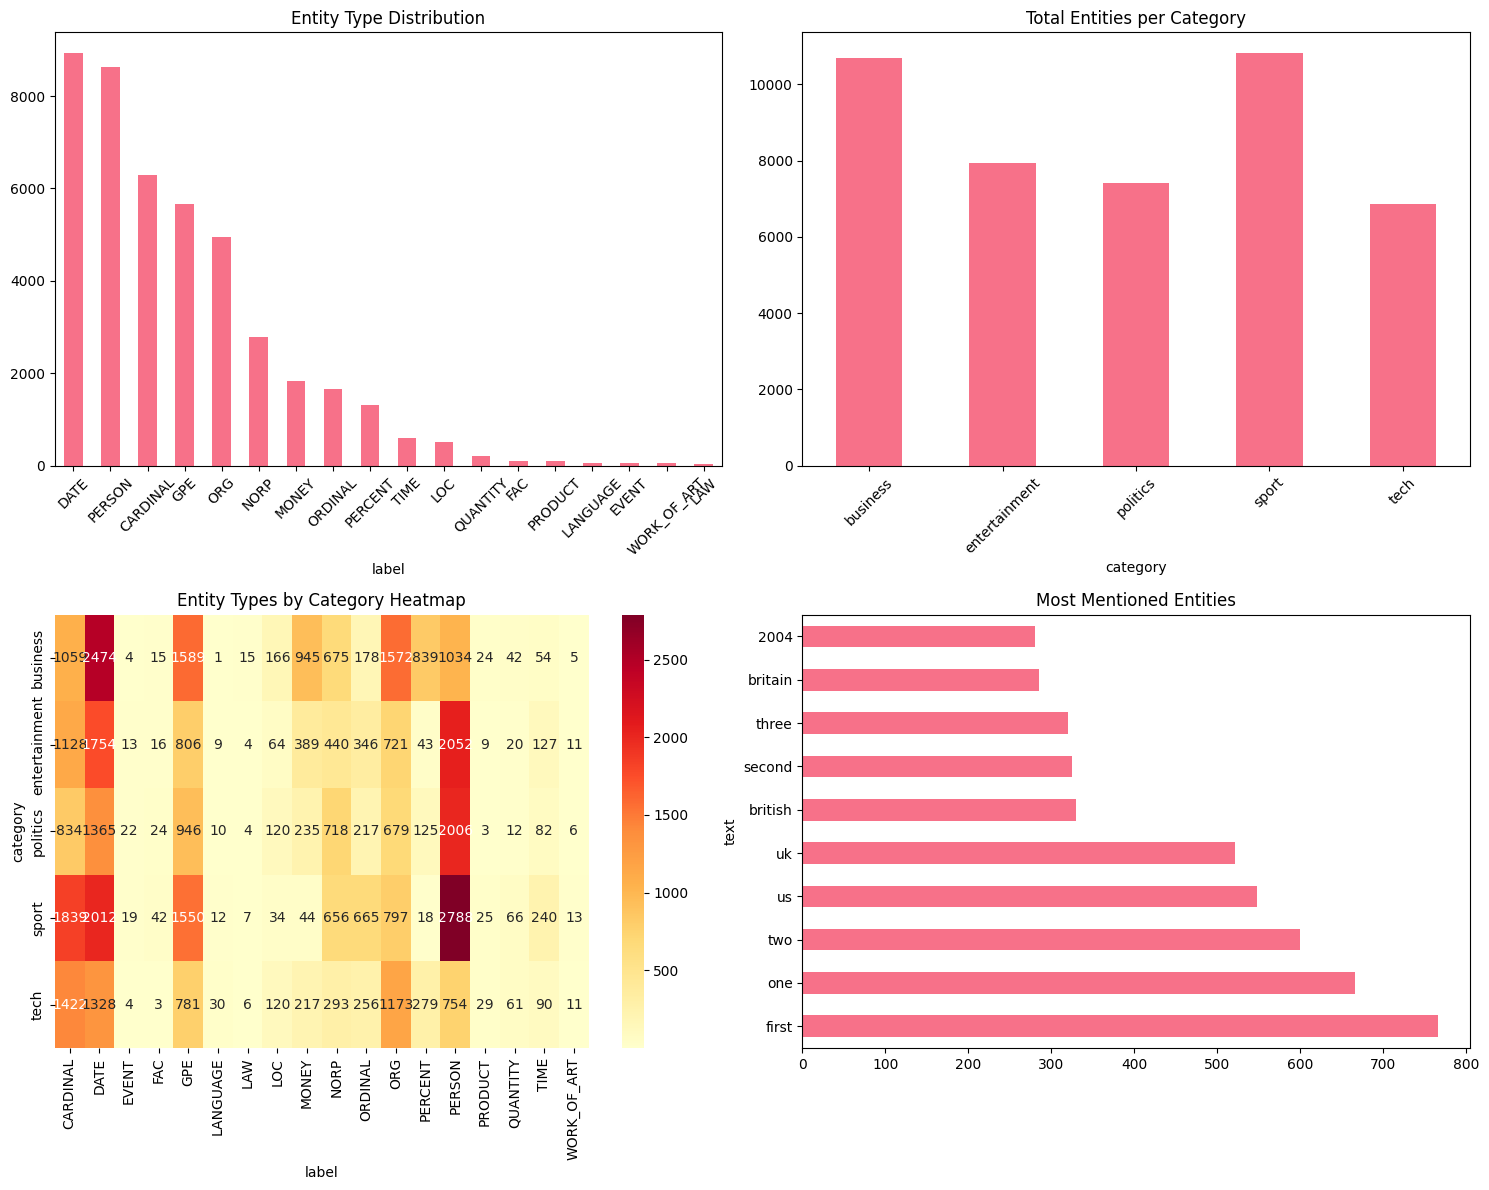


ADVANCED ENTITY ANALYSIS

Top entity co-occurrences:
                 entity_pair  co_mentions
0         blair + tony blair           31
1            blair + britain           30
2           england + france           29
3              bbc + britain           27
4     britain + gordon brown           27
5           britain + london           24
6       britain + tony blair           23
7             france + italy           22
8           france + ireland           21
9           france + germany           20
10      blair + gordon brown           20
11   howard + michael howard           19
12         england + ireland           19
13  britain + michael howard           19
14              bbc + london           18


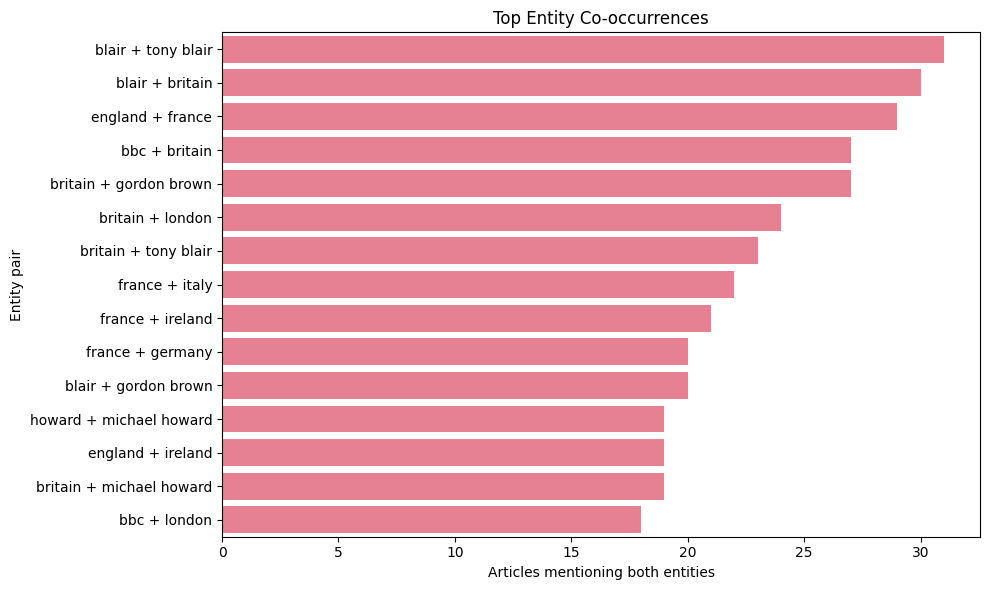


Most common DATE entities:
text
2004         280
2005         249
last year    217
this year    189
2003         176
sunday       158
tuesday      139
wednesday    129
monday       122
friday       120
Name: count, dtype: int64
Note: the BBC dataset has no verified publication dates; the extra-credit section analyzes years mentioned in article text.

Most positive repeated entities:
                       text   label  mentions  avg_sentiment
12978  theatre royal  drury     ORG         3       0.999900
8523               kapranos  PERSON         6       0.999700
2091                   5.05   MONEY         3       0.999700
1898                   4.85   MONEY         3       0.999700
9247               maroon 5    DATE         3       0.999667
7960           jamie graham  PERSON         4       0.999600
10048                nelson  PERSON         3       0.999400
8280                  jolin  PERSON         3       0.999400
6881                    epa     ORG         6       0.999300
854

In [20]:
# Analyze patterns in the named entities extracted from the articles.
from itertools import combinations

if not entities_df.empty:
    print("NAMED ENTITY ANALYSIS")
    print("=" * 50)

    # Count how often each entity type appears.
    entity_counts = entities_df['label'].value_counts()
    print("\nEntity type distribution:")
    print(entity_counts)

    # Compare entity types across news categories.
    entity_by_category = entities_df.groupby(['category', 'label']).size().unstack(fill_value=0)
    print("\nEntity types by news category:")
    print(entity_by_category)

    # Show the most frequently mentioned entities.
    print("\nMost frequent entities:")
    frequent_entities = entities_df.groupby(['text', 'label']).size().sort_values(ascending=False).head(15)

    for (entity, label), count in frequent_entities.items():
        print(f"  {entity} ({label}): {count} mentions")

    # Create visualizations for entity type and category patterns.
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    entity_counts.plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Entity Type Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)

    entities_per_category = entities_df.groupby('category').size()
    entities_per_category.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Total Entities per Category')
    axes[0,1].tick_params(axis='x', rotation=45)

    # Use a heatmap if there is enough data to compare categories and entity labels.
    if entity_by_category.shape[0] > 1 and entity_by_category.shape[1] > 1:
        sns.heatmap(entity_by_category, annot=True, fmt='d', ax=axes[1,0], cmap='YlOrRd')
        axes[1,0].set_title('Entity Types by Category Heatmap')
    else:
        axes[1,0].text(
            0.5,
            0.5,
            'Insufficient data\nfor heatmap',
            ha='center',
            va='center',
            transform=axes[1,0].transAxes
        )
        axes[1,0].set_title('Entity Types by Category')

    top_entities = entities_df['text'].value_counts().head(10)
    top_entities.plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Most Mentioned Entities')

    plt.tight_layout()
    plt.show()

    # Advanced entity analysis: co-occurrence, date entities, and sentiment association.
    print("\nADVANCED ENTITY ANALYSIS")
    print("=" * 50)

    pair_counts = Counter()

    # Count entity pairs that appear in the same article.
    for record in article_entities:
        selected_entities = sorted(set(
            entity['text'].strip()
            for entity in record['entities']
            if entity['label'] in ['PERSON', 'ORG', 'GPE', 'PRODUCT', 'EVENT']
            and len(entity['text'].strip()) > 2
        ))[:12]

        pair_counts.update(combinations(selected_entities, 2))

    # Display and plot the most common entity co-occurrences.
    if pair_counts:
        cooccurrence_df = pd.DataFrame([
            {'entity_pair': f"{pair[0]} + {pair[1]}", 'co_mentions': count}
            for pair, count in pair_counts.most_common(15)
        ])

        print("\nTop entity co-occurrences:")
        print(cooccurrence_df)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=cooccurrence_df, x='co_mentions', y='entity_pair')
        plt.title('Top Entity Co-occurrences')
        plt.xlabel('Articles mentioning both entities')
        plt.ylabel('Entity pair')
        plt.tight_layout()
        plt.show()
    else:
        cooccurrence_df = pd.DataFrame(columns=['entity_pair', 'co_mentions'])
        print("\nNo entity co-occurrences found in the selected entity types.")

    # Show the most common DATE entities detected by spaCy.
    date_entities = entities_df[entities_df['label'] == 'DATE']['text'].value_counts().head(10)

    print("\nMost common DATE entities:")
    print(date_entities if not date_entities.empty else "No DATE entities found.")
    print("Note: the BBC dataset has no verified publication dates; the extra-credit section analyzes years mentioned in article text.")

    # Join entity data with sentiment scores so repeated entities can be linked to article tone.
    entity_sentiment = entities_df.merge(
        sentiment_df[['article_id', 'full_sentiment', 'full_label']],
        on='article_id',
        how='left'
    )

    entity_sentiment_summary = entity_sentiment.groupby(['text', 'label']).agg(
        mentions=('article_id', 'count'),
        avg_sentiment=('full_sentiment', 'mean')
    ).reset_index()

    # Keep only entities that appear several times to avoid weak one-off conclusions.
    entity_sentiment_summary = entity_sentiment_summary[
        entity_sentiment_summary['mentions'] >= 3
    ]

    if not entity_sentiment_summary.empty:
        print("\nMost positive repeated entities:")
        print(entity_sentiment_summary.sort_values('avg_sentiment', ascending=False).head(10))

        print("\nMost negative repeated entities:")
        print(entity_sentiment_summary.sort_values('avg_sentiment', ascending=True).head(10))
    else:
        print("\nNot enough repeated entities for reliable entity-sentiment association.")

else:
    print("Skipping entity analysis due to insufficient data.")
    print("Tip: Try with a larger, more diverse dataset for better NER results.")

## Comprehensive Analysis and Insights

This section combines the project outputs into a single intelligence report: dataset quality, classification performance, sentiment trends, TF-IDF keywords, linguistic patterns, entity findings, and business recommendations.


In [21]:
# Create a final report that combines results from all major analysis sections.
def create_comprehensive_analysis():
    """
    Generate a comprehensive NewsBot intelligence report.

    The report combines dataset quality, classifier performance, TF-IDF
    keywords, sentiment trends, entity findings, linguistic patterns, and
    business recommendations into one dictionary.
    """
    # Create the main structure for the report.
    insights = {
        'dataset_overview': {},
        'classification_performance': {},
        'sentiment_insights': {},
        'entity_insights': {},
        'linguistic_patterns': {},
        'keyword_insights': {},
        'business_recommendations': []
    }

    # Summarize the dataset size, categories, and missing values.
    insights['dataset_overview'] = {
        'total_articles': len(df),
        'categories': df['category'].unique().tolist(),
        'category_distribution': df['category'].value_counts().to_dict(),
        'avg_article_length': df['full_text'].str.len().mean(),
        'avg_words_per_article': df['full_text'].str.split().str.len().mean(),
        'missing_text_values': int(df['content'].isna().sum()),
        'missing_category_values': int(df['category'].isna().sum())
    }

    # Save the best model results and compare all trained classifiers.
    insights['classification_performance'] = {
        'best_model': best_model_name,
        'best_accuracy': results[best_model_name]['accuracy'],
        'best_cv_mean': results[best_model_name]['cv_mean'],
        'model_comparison': {name: results[name]['accuracy'] for name in results.keys()}
    }

    # Summarize sentiment by category.
    sentiment_by_cat = sentiment_df.groupby('category')['full_sentiment'].mean().to_dict()

    insights['sentiment_insights'] = {
        'most_positive_category': max(sentiment_by_cat, key=sentiment_by_cat.get),
        'most_negative_category': min(sentiment_by_cat, key=sentiment_by_cat.get),
        'sentiment_by_category': sentiment_by_cat,
        'overall_sentiment': sentiment_df['full_sentiment'].mean()
    }

    # Add entity findings if named entities were extracted successfully.
    if not entities_df.empty:
        entity_by_cat = entities_df.groupby('category').size().to_dict()

        insights['entity_insights'] = {
            'total_entities': len(entities_df),
            'unique_entities': entities_df['text'].nunique(),
            'entity_types': entities_df['label'].unique().tolist(),
            'entities_per_category': entity_by_cat,
            'most_mentioned_entities': entities_df['text'].value_counts().head(5).to_dict()
        }

    # Include top TF-IDF keywords if the keyword section has already been run.
    if 'category_terms' in globals():
        insights['keyword_insights'] = {
            category: terms.head(5).index.tolist()
            for category, terms in category_terms.items()
        }

    # Include POS and syntax summaries if those sections have already been run.
    if 'pos_interpretation' in globals():
        insights['linguistic_patterns']['pos_summary'] = pos_interpretation.round(4).to_dict()

    if 'syntax_summary' in globals():
        insights['linguistic_patterns']['syntax_summary'] = syntax_summary.round(2).to_dict()

    # Generate short business-style recommendations from the analysis.
    recommendations = []

    if insights['classification_performance']['best_accuracy'] > 0.8:
        recommendations.append("High classification accuracy supports automated content routing.")
    else:
        recommendations.append("Classifier is functional, but more tuning/data could improve automated routing reliability.")

    pos_cat = insights['sentiment_insights']['most_positive_category']
    neg_cat = insights['sentiment_insights']['most_negative_category']

    recommendations.append(f"{pos_cat} articles have the most positive average tone and may support uplifting content recommendations.")
    recommendations.append(f"{neg_cat} articles have the most negative average tone and may need closer editorial monitoring.")

    if insights.get('entity_insights'):
        recommendations.append("Entity extraction enables media monitoring, search, and relationship analysis by people, places, and organizations.")

    if insights.get('keyword_insights'):
        recommendations.append("TF-IDF keywords can be used to explain why the classifier associates articles with specific categories.")

    insights['business_recommendations'] = recommendations

    return insights

# Build the final report dictionary.
print("Generating comprehensive analysis...")
analysis_results = create_comprehensive_analysis()

print("Analysis complete!")
print("\n" + "=" * 60)
print("NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT")
print("=" * 60)

# Display dataset summary.
print("\nDATASET OVERVIEW:")
overview = analysis_results['dataset_overview']
print(f"  Total Articles: {overview['total_articles']}")
print(f"  Categories: {', '.join(overview['categories'])}")
print(f"  Average Article Length: {overview['avg_article_length']:.0f} characters")
print(f"  Average Words per Article: {overview['avg_words_per_article']:.0f} words")
print(f"  Missing Text Values: {overview['missing_text_values']}")
print(f"  Missing Category Values: {overview['missing_category_values']}")

# Display classifier summary.
print("\nCLASSIFICATION PERFORMANCE:")
perf = analysis_results['classification_performance']
print(f"  Best Model: {perf['best_model']}")
print(f"  Best Accuracy: {perf['best_accuracy']:.4f}")
print(f"  Best CV Mean: {perf['best_cv_mean']:.4f}")

# Display sentiment summary.
print("\nSENTIMENT INSIGHTS:")
sent = analysis_results['sentiment_insights']
print(f"  Most Positive Category: {sent['most_positive_category']}")
print(f"  Most Negative Category: {sent['most_negative_category']}")
print(f"  Overall Sentiment: {sent['overall_sentiment']:.4f}")

# Display entity summary if available.
if analysis_results.get('entity_insights'):
    print("\nENTITY INSIGHTS:")
    ent = analysis_results['entity_insights']
    print(f"  Total Entities: {ent['total_entities']}")
    print(f"  Unique Entities: {ent['unique_entities']}")
    print(f"  Entity Types: {', '.join(ent['entity_types'])}")

# Display top keywords by category if available.
if analysis_results.get('keyword_insights'):
    print("\nKEYWORD INSIGHTS:")
    for category, terms in analysis_results['keyword_insights'].items():
        print(f"  {category}: {', '.join(terms)}")

# Display final business recommendations.
print("\nBUSINESS RECOMMENDATIONS:")
for i, rec in enumerate(analysis_results['business_recommendations'], 1):
    print(f"  {i}. {rec}")

Generating comprehensive analysis...
Analysis complete!

NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT

DATASET OVERVIEW:
  Total Articles: 1490
  Categories: business, tech, politics, sport, entertainment
  Average Article Length: 2312 characters
  Average Words per Article: 398 words
  Missing Text Values: 0
  Missing Category Values: 0

CLASSIFICATION PERFORMANCE:
  Best Model: Fast Linear SVM
  Best Accuracy: 0.9866
  Best CV Mean: 0.9706

SENTIMENT INSIGHTS:
  Most Positive Category: entertainment
  Most Negative Category: politics
  Overall Sentiment: 0.3853

ENTITY INSIGHTS:
  Total Entities: 43735
  Unique Entities: 13520
  Entity Types: ORG, PERSON, ORDINAL, GPE, DATE, MONEY, NORP, LOC, CARDINAL, PERCENT, TIME, WORK_OF_ART, EVENT, QUANTITY, FAC, PRODUCT, LANGUAGE, LAW

KEYWORD INSIGHTS:
  business: firm, company, bank, growth, share
  tech: mobile, phone, people, technology, game
  politics: labour, election, blair, party, tory
  sport: game, england, win, player, champio

## Final System Integration

This section wraps the preprocessing, classification, entity extraction, sentiment analysis, and insight generation into one reusable NewsBot class. The final tests show how the bot handles new articles entered by a user.


In [22]:
class NewsBotIntelligenceSystem:
    """
    Complete NewsBot Intelligence System.

    This class combines preprocessing, classification, entity extraction,
    sentiment analysis, and insight generation into one reusable system.
    """

    def __init__(self, classifier, vectorizer, sentiment_analyzer):
        """Store the trained model, TF-IDF vectorizer, sentiment analyzer, and spaCy pipeline."""
        self.classifier = classifier
        self.vectorizer = vectorizer
        self.sentiment_analyzer = sentiment_analyzer
        self.nlp = nlp

    def preprocess_article(self, title, content):
        """Combine title and content, then preprocess the full article text."""
        full_text = f"{title} {content}"
        processed_text = preprocess_text(full_text)
        return full_text, processed_text

    def classify_article(self, title, full_text, processed_text):
        """Classify a new article using the same features used during model training."""

        # Convert the processed article text into TF-IDF features.
        tfidf_features = self.vectorizer.transform([processed_text])

        # Recreate the sentiment features used in training.
        scores = analyze_sentiment(full_text)
        compound_scaled = (scores["compound"] + 1) / 2
        sentiment_features = np.array([
            [compound_scaled, scores["pos"], scores["neu"], scores["neg"]]
        ])

        # Recreate the scaled length features used in training.
        length_features = np.array(
            [[len(full_text), len(full_text.split()), len(title)]],
            dtype=float
        )
        length_features = length_features / length_feature_max

        # Combine TF-IDF, sentiment, and length features.
        extra_features = csr_matrix(np.hstack([sentiment_features, length_features]))
        combined = hstack([tfidf_features, extra_features]).tocsr()

        # Predict the article category.
        prediction = self.classifier.predict(combined)[0]

        # Some models have probabilities; LinearSVC uses decision scores instead.
        if hasattr(self.classifier, "predict_proba"):
            probabilities = self.classifier.predict_proba(combined)[0]
        else:
            scores_array = self.classifier.decision_function(combined)
            scores_array = np.ravel(scores_array)
            exp_scores = np.exp(scores_array - np.max(scores_array))
            probabilities = exp_scores / exp_scores.sum()

        return prediction, dict(zip(self.classifier.classes_, probabilities))

    def extract_entities(self, text):
        """Extract named entities from article text."""
        return extract_entities(text)

    def analyze_sentiment(self, text):
        """Analyze article sentiment."""
        return analyze_sentiment(text)

    def process_article(self, title, content):
        """
        Run the full NewsBot pipeline on a new article.

        Returns category prediction, confidence, entity extraction,
        sentiment analysis, and generated insights.
        """
        # Step 1: Prepare the text.
        full_text, processed_text = self.preprocess_article(title, content)

        # Step 2: Predict the article category.
        category, category_probs = self.classify_article(title, full_text, processed_text)

        # Step 3: Extract named entities.
        entities = self.extract_entities(full_text)

        # Step 4: Analyze sentiment.
        sentiment = self.analyze_sentiment(full_text)

        # Step 5: Generate readable insights.
        insights = self.generate_insights(category, entities, sentiment, category_probs)

        return {
            'title': title,
            'content': content[:200] + '...' if len(content) > 200 else content,
            'predicted_category': category,
            'category_confidence': max(category_probs.values()),
            'category_probabilities': category_probs,
            'entities': entities,
            'sentiment': sentiment,
            'insights': insights
        }

    def generate_insights(self, category, entities, sentiment, category_probs):
        """Generate short, readable insights from the model outputs."""
        insights = []

        # Add classification confidence insight.
        confidence = max(category_probs.values())
        if confidence > 0.8:
            insights.append(f"High confidence {category} classification ({confidence:.2%})")
        else:
            insights.append("Uncertain classification - consider manual review")

        # Add sentiment insight.
        if sentiment['compound'] > 0.1:
            insights.append(f"Positive sentiment detected ({sentiment['compound']:.3f})")
        elif sentiment['compound'] < -0.1:
            insights.append(f"Negative sentiment detected ({sentiment['compound']:.3f})")
        else:
            insights.append(f"Neutral sentiment ({sentiment['compound']:.3f})")

        # Add entity insight.
        if entities:
            entity_types = set([e['label'] for e in entities])
            insights.append(f"Found {len(entities)} entities of {len(entity_types)} types")

            important_entities = [
                e for e in entities
                if e['label'] in ['PERSON', 'ORG', 'GPE']
            ]

            if important_entities:
                key_entities = [e['text'] for e in important_entities[:3]]
                insights.append(f"Key entities: {', '.join(key_entities)}")
        else:
            insights.append("No named entities detected")

        return insights

# Initialize the final NewsBot system with the best trained model.
newsbot = NewsBotIntelligenceSystem(
    classifier=best_model,
    vectorizer=tfidf_vectorizer,
    sentiment_analyzer=sia
)

print("NewsBot Intelligence System initialized!")
print("Ready to process new articles")

NewsBot Intelligence System initialized!
Ready to process new articles


In [23]:
# Test the completed NewsBot system with new example articles.
print("TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# These examples represent different types of news content.
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': "Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and enhance cloud computing services."
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Store a short summary of each test result.
test_results = []

for i, article in enumerate(test_articles, 1):
    print(f"\nTEST ARTICLE {i}")
    print("-" * 40)

    # Run the full NewsBot pipeline on the test article.
    result = newsbot.process_article(article['title'], article['content'])

    # Save the most important outputs for the final reflection table.
    test_results.append({
        'title': article['title'],
        'predicted_category': result['predicted_category'],
        'confidence': result['category_confidence'],
        'sentiment': result['sentiment']['sentiment_label'],
        'entity_count': len(result['entities'])
    })

    print(f"Title: {result['title']}")
    print(f"Content: {result['content']}")
    print(f"\nPredicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")

    # Display category probabilities from highest to lowest.
    print("\nCategory Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")

    print(f"\nSentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")

    # Show up to five detected entities.
    if result['entities']:
        print(f"\nEntities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print("\nNo entities detected")

    # Show the final generated insights.
    print("\nInsights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("NewsBot Intelligence System testing complete!")
print("System successfully processed all test articles")

# Create a simple summary table for the test articles.
print("\nSYSTEM TEST REFLECTION")
print("=" * 60)

test_results_df = pd.DataFrame(test_results)
print(test_results_df)

print("\nStrengths: the bot combines category prediction, sentiment, entity extraction, and explanation-style insights in one workflow.")
print("Limitations: the classifier can only predict the BBC training categories, so topics outside those labels are mapped to the closest available category.")
print("Improvement path: add newer articles, more categories such as health, and evaluate more custom NER examples.")

TESTING NEWSBOT INTELLIGENCE SYSTEM

TEST ARTICLE 1
----------------------------------------
Title: Microsoft Acquires AI Startup for $2 Billion
Content: Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and en...

Predicted Category: tech (29.42% confidence)

Category Probabilities:
  tech: 0.294
  business: 0.207
  politics: 0.184
  entertainment: 0.175
  sport: 0.140

Sentiment: positive (score: 0.660)

Entities Found (8):
  Microsoft Acquires (ORG) - Companies, agencies, institutions, etc.
  $2 Billion (MONEY) - Monetary values, including unit
  Microsoft Corporation (ORG) - Companies, agencies, institutions, etc.
  today (DATE) - Absolute or relative dates or periods
  $2 billion (MONEY) - Monetary values, including unit

Insights:
  Uncertain classification - consider manual review
  Positive sentiment detected (0.660)
  Found 8 entities 

## Extra Credit Features

This organized section targets the available extra-credit opportunities:

- Interactive Dashboard (5 pts): a Gradio interface where a user can paste an article and receive category, sentiment, entities, and insights.
- Advanced Analysis (5 pts): temporal-reference trend analysis using years mentioned inside articles, because this BBC training file does not include verified publication dates.
- Custom Models (5 pts): domain-specific NER through a news entity ruler plus a small custom NER training demonstration.

### Extra Credit 1: Custom news-domain NER

The first extra-credit feature extends standard spaCy NER with news-specific labels such as TECH_COMPANY, SPORTS_LEAGUE, POLITICAL_ORG, and NEWS_SOURCE. The following cells also include a small custom NER training demonstration from hand-labeled examples.


In [24]:
# Extra Credit: add domain-specific news entities with spaCy's EntityRuler.

# Remove the ruler first if this cell has already been run.
# This prevents duplicate pipeline components.
if "news_domain_ruler" in nlp.pipe_names:
    nlp.remove_pipe("news_domain_ruler")

# Add a rule-based entity recognizer after spaCy's standard NER model.
ruler = nlp.add_pipe(
    "entity_ruler",
    name="news_domain_ruler",
    after="ner",
    config={"overwrite_ents": True}
)

# Add custom patterns for news-related entities.
ruler.add_patterns([
    {"label": "TECH_COMPANY", "pattern": "OpenAI"},
    {"label": "TECH_COMPANY", "pattern": "Microsoft"},
    {"label": "TECH_COMPANY", "pattern": "Google"},
    {"label": "TECH_COMPANY", "pattern": "Apple"},
    {"label": "NEWS_SOURCE", "pattern": "BBC"},
    {"label": "NEWS_SOURCE", "pattern": "Reuters"},
    {"label": "SPORTS_LEAGUE", "pattern": "NBA"},
    {"label": "SPORTS_LEAGUE", "pattern": "NFL"},
    {"label": "SPORTS_LEAGUE", "pattern": "FIFA"},
    {"label": "POLITICAL_ORG", "pattern": "White House"},
    {"label": "POLITICAL_ORG", "pattern": "United Nations"},
    {"label": "POLITICAL_ORG", "pattern": "Congress"}
])

# Test the custom entity rules on a short example sentence.
custom_rule_demo = nlp(
    "Reuters reported that OpenAI, Microsoft, the NBA, and the United Nations were mentioned in separate news stories."
)

print("News-domain entity rules loaded.")
print("Rule-based custom NER demo:", [(ent.text, ent.label_) for ent in custom_rule_demo.ents])

News-domain entity rules loaded.
Rule-based custom NER demo: [('Reuters', 'NEWS_SOURCE'), ('OpenAI', 'TECH_COMPANY'), ('Microsoft', 'TECH_COMPANY'), ('NBA', 'SPORTS_LEAGUE'), ('United Nations', 'POLITICAL_ORG')]


In [26]:
# Extra Credit: demonstrate a small custom NER training workflow.
# This is a tiny example for Colab, not a production-level model.
from spacy.training import Example
import random

# Hand-labeled training examples for custom news-related entity types.
train_data = [
    ("OpenAI released a research model.", {"entities": [(0, 6, "TECH_COMPANY")]}),
    ("Microsoft announced cloud investments.", {"entities": [(0, 9, "TECH_COMPANY")]}),
    ("Google launched a search feature.", {"entities": [(0, 6, "TECH_COMPANY")]}),
    ("Apple expanded its services business.", {"entities": [(0, 5, "TECH_COMPANY")]}),
    ("The NBA confirmed the playoff schedule.", {"entities": [(4, 7, "SPORTS_LEAGUE")]}),
    ("The NFL announced a broadcast deal.", {"entities": [(4, 7, "SPORTS_LEAGUE")]}),
    ("The White House released a statement.", {"entities": [(4, 15, "POLITICAL_ORG")]}),
    ("The United Nations held climate talks.", {"entities": [(4, 18, "POLITICAL_ORG")]}),
]

# Create a blank spaCy pipeline and add a trainable NER component.
custom_ner_nlp = spacy.blank("en")
ner = custom_ner_nlp.add_pipe("ner")

# Register each custom entity label with the NER component.
for _, annotations in train_data:
    for _, _, label in annotations["entities"]:
        ner.add_label(label)

# Convert training data into spaCy Example objects.
examples = [
    Example.from_dict(custom_ner_nlp.make_doc(text), ann)
    for text, ann in train_data
]

# Initialize the model before training.
optimizer = custom_ner_nlp.initialize(lambda: examples)

# Train for a small number of iterations so it runs quickly in Colab.
for _ in range(25):
    random.shuffle(examples)
    custom_ner_nlp.update(examples, sgd=optimizer, drop=0.2)

# Test the small custom model on new sentences.
demo_texts = [
    "OpenAI and the NBA announced separate events.",
    "Microsoft and the United Nations appeared in the report.",
    "The NFL and Google signed media partnerships."
]

for demo_text in demo_texts:
    demo_doc = custom_ner_nlp(demo_text)
    print(demo_text, "->", [(entity.text, entity.label_) for entity in demo_doc.ents])

OpenAI and the NBA announced separate events. -> [('OpenAI', 'TECH_COMPANY'), ('NBA', 'TECH_COMPANY')]
Microsoft and the United Nations appeared in the report. -> [('Microsoft', 'TECH_COMPANY')]
The NFL and Google signed media partnerships. -> [('NFL', 'TECH_COMPANY'), ('Google', 'TECH_COMPANY')]


### Extra Credit 2: Advanced temporal-reference analysis

The BBC training file does not include verified publication dates. Instead of inventing dates, this analysis counts explicit four-digit years mentioned inside articles by category. This measures temporal references in coverage, not publication volume.


Temporal reference summary:
category        business  entertainment  politics  sport  tech
year_mentioned                                                
2008                11.0            0.0      10.0    6.0   8.0
2009                 3.0            0.0       0.0    0.0   9.0
2010                 9.0            3.0       3.0    0.0   8.0
2011                 1.0            0.0       2.0    0.0   0.0
2012                 1.0            1.0       3.0    1.0   0.0
2013                 0.0            0.0       2.0    0.0   0.0
2014                 3.0            1.0       0.0    0.0   0.0
2015                 2.0            0.0       2.0    0.0   1.0
2018                 1.0            0.0       0.0    0.0   0.0
2019                 1.0            0.0       0.0    0.0   0.0
2020                 2.0            0.0       0.0    0.0   1.0
2022                 0.0            0.0       1.0    0.0   0.0
2025                 0.0            0.0       0.0    0.0   2.0
2048                 0.0   

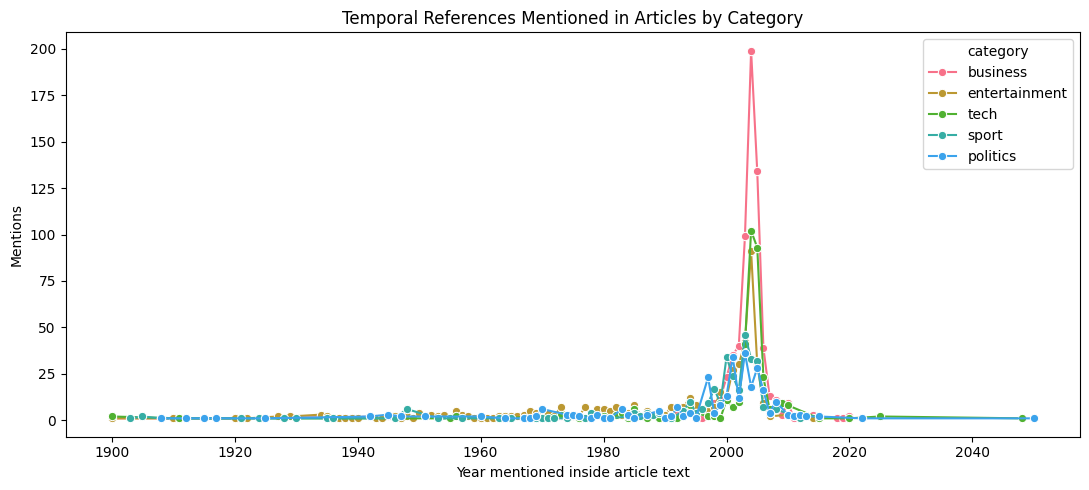

In [27]:
# Extra Credit: analyze year references mentioned inside article text.
# The BBC dataset has no publication dates, so this uses years found in the article content.
temporal_rows = []

# Extract four-digit years such as 1999, 2004, or 2020 from each article.
for _, article in df.iterrows():
    for year in re.findall(r"\b(?:19|20)\d{2}\b", article["content"]):
        temporal_rows.append({
            "category": article["category"],
            "year_mentioned": int(year)
        })

# Convert extracted year references into a dataframe.
temporal_df = pd.DataFrame(temporal_rows)

if temporal_df.empty:
    print("No four-digit years were found.")
else:
    # Count year mentions by category.
    temporal_counts = (
        temporal_df
        .groupby(["year_mentioned", "category"])
        .size()
        .reset_index(name="mentions")
    )

    # Create a pivot table for a compact category-by-year summary.
    temporal_pivot = temporal_counts.pivot_table(
        index='year_mentioned',
        columns='category',
        values='mentions',
        fill_value=0
    )

    print("Temporal reference summary:")
    print(temporal_pivot.tail(15))

    print("\nMost frequently mentioned years:")
    print(temporal_df['year_mentioned'].value_counts().head(10))

    # Plot year mentions over time by category.
    plt.figure(figsize=(11, 5))
    sns.lineplot(
        data=temporal_counts,
        x="year_mentioned",
        y="mentions",
        hue="category",
        marker="o"
    )

    plt.title("Temporal References Mentioned in Articles by Category")
    plt.xlabel("Year mentioned inside article text")
    plt.ylabel("Mentions")
    plt.tight_layout()
    plt.show()

### Extra Credit 3: Interactive Gradio NewsBot dashboard

Run this after the final NewsBot test. The dashboard lets a user paste a headline and article text, then returns the predicted category, sentiment, named entities, and NewsBot insights.


In [28]:
# Extra Credit: install and import Gradio for the interactive dashboard.
!pip -q install gradio
import gradio as gr

def dashboard_analyze(title, content):
    """
    Analyze user-provided article text for the Gradio dashboard.

    Returns category probabilities, sentiment, extracted entities, and
    generated NewsBot insights in dashboard-friendly formats.
    """
    try:
        # Run the full NewsBot pipeline on the user's input.
        result = newsbot.process_article(title, content)

        # Format entities and insights so they display cleanly in the dashboard.
        entities = "\n".join(
            f"- {x['text']} — {x['label']}"
            for x in result["entities"][:12]
        ) or "No entities found."

        insights = "\n".join(
            f"- {x}"
            for x in result["insights"]
        )

        sentiment = (
            f"**{result['sentiment']['sentiment_label'].title()}** "
            f"(VADER: {result['sentiment']['compound']:.2f})"
        )

        return result["category_probabilities"], sentiment, entities, insights

    except Exception as error:
        # Return a readable error message if the user input causes a problem.
        return {}, f"Input issue: {error}", "", ""

# Build a simple Gradio interface for the NewsBot.
with gr.Blocks(theme=gr.themes.Soft(), title="NewsBot") as demo:
    gr.Markdown("# NewsBot Intelligence System")
    gr.Markdown("Paste a news article to classify its category, sentiment, entities, and main insights.")

    title_input = gr.Textbox(label="Headline, optional")
    content_input = gr.Textbox(label="Article text", lines=12)
    button = gr.Button("Analyze article", variant="primary")

    category_output = gr.Label(label="Predicted category", num_top_classes=5)
    sentiment_output = gr.Markdown(label="Sentiment")
    entity_output = gr.Markdown(label="Entities")
    insight_output = gr.Markdown(label="Insights")

    # Connect the button to the dashboard analysis function.
    button.click(
        dashboard_analyze,
        [title_input, content_input],
        [category_output, sentiment_output, entity_output, insight_output]
    )

# Launch the dashboard inside Colab.
demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [ ] Complete Jupyter notebook with all analyses
- [ ] Well-documented functions with docstrings
- [ ] Clear markdown explanations for each section
- [ ] Organized GitHub repository structure
- [ ] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [ ] Comprehensive dataset exploration
- [ ] TF-IDF analysis with category-specific insights
- [ ] POS tagging patterns across categories
- [ ] Syntactic analysis with dependency parsing
- [ ] Sentiment analysis with category comparisons
- [ ] Classification model comparison and evaluation
- [ ] Named Entity Recognition with relationship mapping
- [ ] Integrated system demonstration

### 📈 Visualizations
- [ ] Category distribution plots
- [ ] TF-IDF word clouds or bar charts
- [ ] POS pattern heatmaps
- [ ] Sentiment distribution by category
- [ ] Confusion matrix for classification
- [ ] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [ ] Written report (3-4 pages)
- [ ] Individual reflection papers
- [ ] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*